In [1]:
# imports
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import (
    KFold
)
from sklearn.preprocessing import (
  OneHotEncoder
)
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score, auc,
    precision_recall_curve, average_precision_score
)

from imblearn.under_sampling import RandomUnderSampler

import data_preprocessing
import data_models

# focal loss needs one hot encoding
from keras.utils import to_categorical

## functions

In [2]:
# flattens array
def flatten(subject):
    array_data = [np.array(x) for x in subject] 
    flattened_data = np.concatenate(array_data, axis=0)
    return flattened_data

In [3]:
def create_X_Y(df, feature, sample_count= 25, hours = 2, modus = "h"):
    # generates time series with sliding window approach
    result = df.groupby('PtID').apply(lambda g: data_preprocessing.extract_valid_windows_GLC_HR(g, expected_sample_count = sample_count,
    min_window_duration = np.timedelta64(hours, 'h')))

    # filters out None values of subjects with insufficient data
    filtered_result = [item for item in result if item is not None]
    # unpacks the values
    X_data, Y_data = zip(*filtered_result)

    return X_data, Y_data

In [4]:
# ensure reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

def undersampling(X, y):
    # ensures labels are 1D
    if y.ndim == 2 and y.shape[1] == 1:
        y = y.ravel()

    # saves original shape
    num_samples, window_size, num_channels = X.shape
    # flattens for resampling
    X_reshaped = X.reshape(num_samples, -1)  

    # defines undersampling strategy: equalize all classes
    min_class_count = min(Counter(y).values())
    sampling_strategy = {int(cls): min_class_count for cls in np.unique(y)}

    # applies undersampling
    rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_under, y_under = rus.fit_resample(X_reshaped, y)

    # reshapes X back to original 3D shape
    X_under = X_under.reshape(-1, window_size, num_channels)
    y_under = y_under.reshape(-1, 1)

    return X_under, y_under  # y_under is 1D

## Read, clean data, and preprocess data

In [ ]:
subdatabaseII = pl.read_csv("DiaData/datasets for T1D/SDBII_raw.csv")
subdatabaseII = subdatabaseII.sort(["PtID", "ts"])
# converts the timestamp column to datetime
subdatabaseII = subdatabaseII.to_pandas()
subdatabaseII["ts"] = pd.to_datetime(subdatabaseII["ts"])

# calls function remove_outliers() for glucose and heart rate columns based on the IQR method
data_cleaned_glc = data_preprocessing.remove_outliers(subdatabaseII, value = "GlucoseCGM", modus = "glucose", subject = "PtID")
data_cleaned = data_preprocessing.remove_outliers(data_cleaned_glc, value = "HR", modus = "vitals", subject = "PtID")  

# linear interpolation is used for gaps which are less than 30 minute (6 consecuitve datapoints)
# first for glucose then for heart rate values by callign the function gap_limited_interpolation()
df_interpolated = data_cleaned.copy()
df_interpolated = df_interpolated.sort_values("ts")
df_interpolated['GlucoseCGM'] = df_interpolated.groupby('PtID')['GlucoseCGM'].transform(
    lambda x: data_preprocessing.gap_limited_interpolation(x, limit=6)
)

df_interpolated['HR'] = df_interpolated.groupby('PtID')['HR'].transform(
    lambda x: data_preprocessing.gap_limited_interpolation(x, limit=6)
)

# then gaps between 30 and 120 min are imputed with stine interpolation separately for glucose and heart rate 
df_interpolated_stine = df_interpolated.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.interpolate_stineman_group(x, timestamp = "ts", value = "GlucoseCGM", llimit=6, ulimit=24))
# index is sorted 
df_interpolated_stine = df_interpolated_stine.sort_index()
df_interpolated_stine = df_interpolated.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.interpolate_stineman_group(x, timestamp = "ts", value = "HR", llimit=6, ulimit=24))
# index is sorted 
df_interpolated_stine = df_interpolated_stine.sort_index()

# dataset with interpolated values is copied
classes_df = df_interpolated_stine.copy()
# initially all classes are assigned the class -1
classes_df["Class"] = -1
# hypoglycemic values are defined as class 0 with values equal and lower than 70 mg/dL
classes_df.loc[classes_df["GlucoseCGM"] <= 70, "Class"] = 0

# calls the function class_generation to assing classes based on wanted intervals before hypogylcemia for each subject separately
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 5, 15, 1)) # 5-15 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 15, 30, 2)) # 15-30 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 30, 60, 3))  # 30-60 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts",  60, 125, 4)) # 1-2 h
classes_df.loc[classes_df["Class"] == -1, "Class"] = 5

# sorts the glucose values by patient id and timestamps
df_sorted = classes_df.sort_values(by=['PtID', 'ts'])
# reindexes based on the sorted dataset
df_sorted = df_sorted.reset_index(drop=True)

# prints the number of each value accross classes
df_sorted["Class"].value_counts()

Class
5    1480967
0      39842
4      39028
3      20174
2      10726
1       7416
Name: count, dtype: int64

In [9]:
# normalizes data 
df_min_max_scaled = data_preprocessing.normalize_data(df_sorted, 'GlucoseCGM')
df_min_max_scaled = data_preprocessing.normalize_data(df_min_max_scaled, 'HR')	

# missing values in the heart rate column are replaced with zero
df_min_max_scaled["HR"] = df_min_max_scaled['HR'].fillna(0)

## Train FCN vs ResNet with 2h ISL

In [ ]:
# creates time series sequences of 2 hours corresponding to 25 consecutive datapoints
X_data, Y_data = create_X_Y(df_min_max_scaled, "PtID", 25,2, 'h')

2025-09-18 00:45:33.376561: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-18 00:45:33.376582: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-18 00:45:33.830428: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:50:36.596463: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/316 [..............................] - ETA: 1:00

2025-09-18 00:50:38.048025: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


316/316 [==============================] - 1s 2ms/step


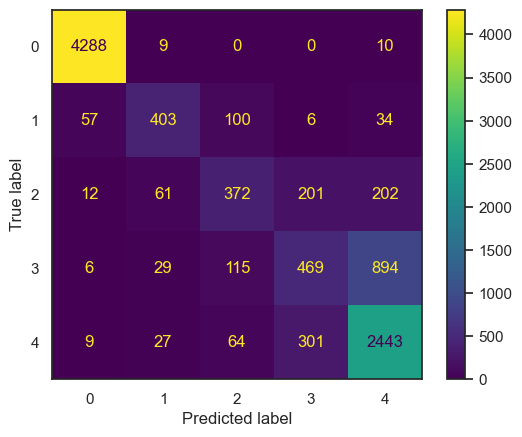

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9808    0.9956    0.9881      4307
           1     0.7618    0.6717    0.7139       600
           2     0.5714    0.4387    0.4963       848
           3     0.4800    0.3100    0.3767      1513
           4     0.6818    0.8590    0.7602      2844

    accuracy                         0.7887     10112
   macro avg     0.6952    0.6550    0.6671     10112
weighted avg     0.7745    0.7887    0.7750     10112

Saved report for FCN fold 0
Bootstrapped Macro F1: 0.6670
95% CI: (0.6558, 0.6789)
Started for fold 1


2025-09-18 00:50:41.758820: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:55:26.729740: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/524 [..............................] - ETA: 1:44

2025-09-18 00:55:29.571948: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


524/524 [==============================] - 1s 2ms/step


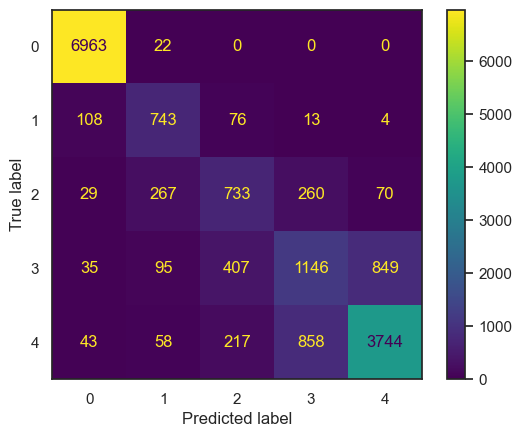

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9700    0.9969    0.9833      6985
           1     0.6270    0.7871    0.6980       944
           2     0.5115    0.5394    0.5251      1359
           3     0.5033    0.4526    0.4766      2532
           4     0.8022    0.7610    0.7811      4920

    accuracy                         0.7962     16740
   macro avg     0.6828    0.7074    0.6928     16740
weighted avg     0.7936    0.7962    0.7939     16740

Saved report for FCN fold 1
Bootstrapped Macro F1: 0.6925
95% CI: (0.6835, 0.7014)
Started for fold 2


2025-09-18 00:55:35.396381: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:59:04.367089: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1180/1180 [==============================] - 6s 4ms/step - loss: 0.5962 - sparse_categorical_accuracy: 0.7388


2025-09-18 00:59:09.983540: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1180/1180 [==============================] - 2s 2ms/step


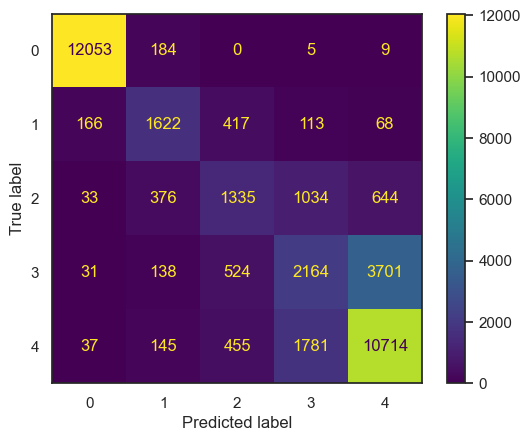

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9783    0.9838    0.9811     12251
           1     0.6580    0.6798    0.6687      2386
           2     0.4888    0.3901    0.4339      3422
           3     0.4246    0.3300    0.3713      6558
           4     0.7078    0.8159    0.7580     13132

    accuracy                         0.7388     37749
   macro avg     0.6515    0.6399    0.6426     37749
weighted avg     0.7234    0.7388    0.7282     37749

Saved report for FCN fold 2
Bootstrapped Macro F1: 0.6426
95% CI: (0.6371, 0.6481)
Started for fold 3


2025-09-18 00:59:22.437924: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 01:04:18.517261: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/331 [..............................] - ETA: 1:07

2025-09-18 01:04:20.365904: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


331/331 [==============================] - 1s 2ms/step


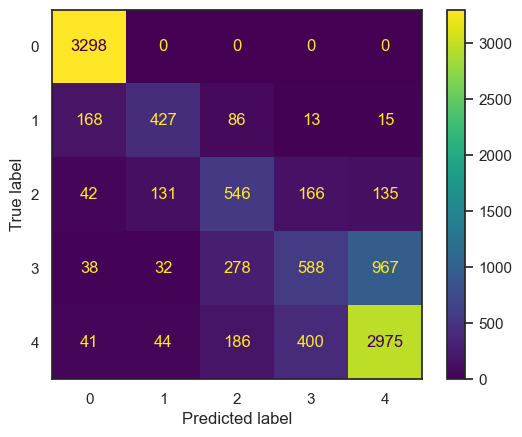

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9194    1.0000    0.9580      3298
           1     0.6735    0.6023    0.6359       709
           2     0.4982    0.5353    0.5161      1020
           3     0.5039    0.3090    0.3831      1903
           4     0.7270    0.8160    0.7689      3646

    accuracy                         0.7407     10576
   macro avg     0.6644    0.6525    0.6524     10576
weighted avg     0.7212    0.7407    0.7252     10576

Saved report for FCN fold 3
Bootstrapped Macro F1: 0.6522
95% CI: (0.6411, 0.6627)
Started for fold 4


2025-09-18 01:04:24.358297: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 01:08:28.634008: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/837 [..............................] - ETA: 2:52

2025-09-18 01:08:32.519467: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


837/837 [==============================] - 2s 2ms/step


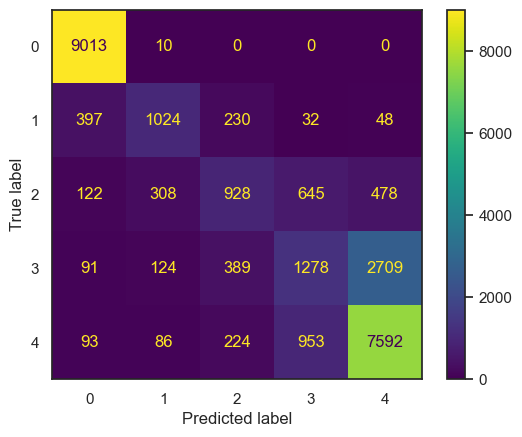

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9276    0.9989    0.9620      9023
           1     0.6598    0.5916    0.6238      1731
           2     0.5240    0.3740    0.4365      2481
           3     0.4395    0.2784    0.3408      4591
           4     0.7012    0.8485    0.7678      8948

    accuracy                         0.7408     26774
   macro avg     0.6504    0.6183    0.6262     26774
weighted avg     0.7135    0.7408    0.7200     26774

Saved report for FCN fold 4
Bootstrapped Macro F1: 0.6262
95% CI: (0.6191, 0.6331)
Report for FCN


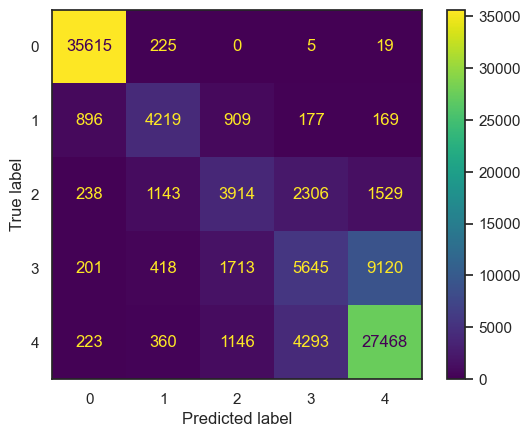

              precision    recall  f1-score   support

           0     0.9581    0.9931    0.9753     35864
           1     0.6628    0.6623    0.6626      6370
           2     0.5095    0.4287    0.4656      9130
           3     0.4543    0.3302    0.3824     17097
           4     0.7171    0.8202    0.7652     33490

    accuracy                         0.7539    101951
   macro avg     0.6604    0.6469    0.6502    101951
weighted avg     0.7358    0.7539    0.7417    101951



In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
# for faster training 
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


# intializes 5 folds for 5 fold cross validation
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All = []
predicted_labels_fcn_All = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):

        average_precisions = []
        PRauc_scores = []
        # the dataset is split into training and validation sets for the current fold
        #print(train_idx)
        #print(test_idx)
        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,25,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,25,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output", dim = 1)


        # initiliazes buffer size and batch size 
        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_rs, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_rs, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


        # sets the learning rate of the Adam optimizer 
        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)

        # builds and trains the model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['sparse_categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        ConfusionMatrixDisplay.from_predictions(Y_test_t, y_pred_fcn)
        plt.show()

        
        report_fcn = classification_report(Y_test_t, y_pred_fcn, digits=4)
        print(report_fcn)


        actual_labels_All.append(Y_test_t)
        predicted_labels_fcn_All.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper = data_models.bootstrap_macro_f1(np.array(Y_test_t), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_t, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_t, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_t, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_t,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
        targ_multi = enc.fit_transform(Y_test_fold.reshape(-1, 1))
        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(targ_multi[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            ap_score = average_precision_score(targ_multi[:, cl], predictions_fcn[:, cl])
            average_precisions.append(ap_score)
            PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)


        count = count + 1


# POPULATION
print("Report for FCN using 2h")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All), axis=1) 
ConfusionMatrixDisplay.from_predictions(flatten(actual_labels_All), y_pred_fcn)
plt.show()
# calculating metric
print(classification_report(flatten(actual_labels_All), y_pred_fcn, digits=4))

# saves the calculated metrics in txt file
with open("FCN_5Fold_2h_CCEL.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

2025-09-18 09:11:51.899886: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-18 09:11:51.899912: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-18 09:11:54.302377: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 09:31:44.950383: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


316/316 [==============================] - 5s 9ms/step - loss: 0.9808 - sparse_categorical_accuracy: 0.7159


2025-09-18 09:31:49.970995: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


316/316 [==============================] - 4s 6ms/step


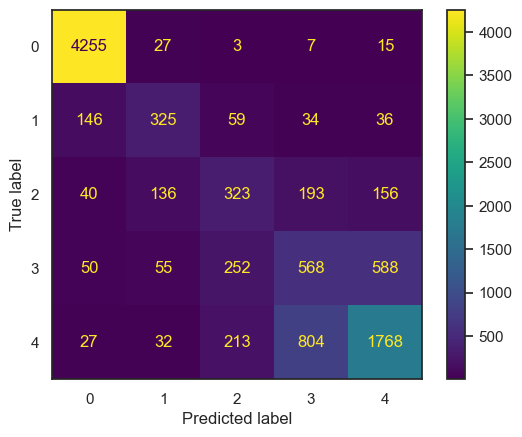

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9418    0.9879    0.9643      4307
           1     0.5652    0.5417    0.5532       600
           2     0.3800    0.3809    0.3804       848
           3     0.3537    0.3754    0.3642      1513
           4     0.6898    0.6217    0.6540      2844

    accuracy                         0.7159     10112
   macro avg     0.5861    0.5815    0.5832     10112
weighted avg     0.7135    0.7159    0.7139     10112

Saved report for ResNet fold 0
Bootstrapped Macro F1: 0.5830
95% CI: (0.5719, 0.5948)
Started for fold 1


2025-09-18 09:31:58.854565: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 09:49:47.424338: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


524/524 [==============================] - 8s 11ms/step - loss: 0.8712 - sparse_categorical_accuracy: 0.7388


2025-09-18 09:49:55.709339: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


524/524 [==============================] - 5s 7ms/step


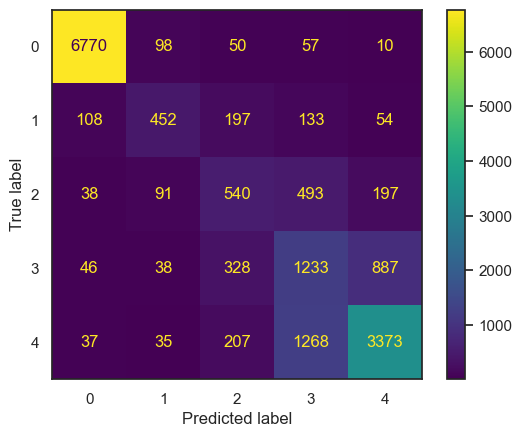

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9673    0.9692    0.9682      6985
           1     0.6331    0.4788    0.5452       944
           2     0.4085    0.3974    0.4028      1359
           3     0.3872    0.4870    0.4314      2532
           4     0.7461    0.6856    0.7145      4920

    accuracy                         0.7388     16740
   macro avg     0.6284    0.6036    0.6125     16740
weighted avg     0.7503    0.7388    0.7427     16740

Saved report for ResNet fold 1
Bootstrapped Macro F1: 0.6122
95% CI: (0.6038, 0.6212)
Started for fold 2


2025-09-18 09:50:08.372247: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 10:03:39.419937: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1180/1180 [==============================] - 13s 9ms/step - loss: 1.0662 - sparse_categorical_accuracy: 0.6719


2025-09-18 10:03:52.313681: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1180/1180 [==============================] - 8s 6ms/step


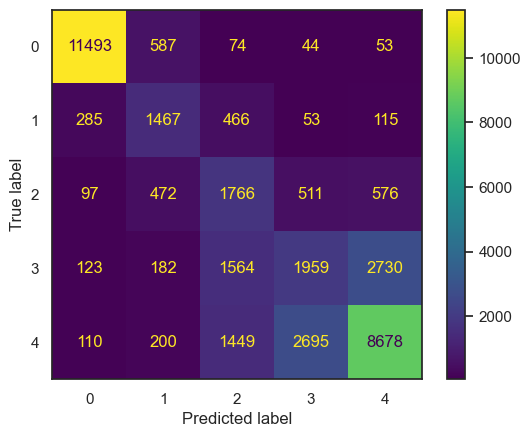

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9492    0.9381    0.9436     12251
           1     0.5045    0.6148    0.5542      2386
           2     0.3320    0.5161    0.4041      3422
           3     0.3723    0.2987    0.3315      6558
           4     0.7141    0.6608    0.6864     13132

    accuracy                         0.6719     37749
   macro avg     0.5744    0.6057    0.5840     37749
weighted avg     0.6831    0.6719    0.6743     37749

Saved report for ResNet fold 2
Bootstrapped Macro F1: 0.5841
95% CI: (0.5786, 0.5893)
Started for fold 3


2025-09-18 10:04:16.618366: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 10:22:31.958353: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


331/331 [==============================] - 5s 11ms/step - loss: 1.0897 - sparse_categorical_accuracy: 0.6931


2025-09-18 10:22:37.396475: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


331/331 [==============================] - 4s 8ms/step


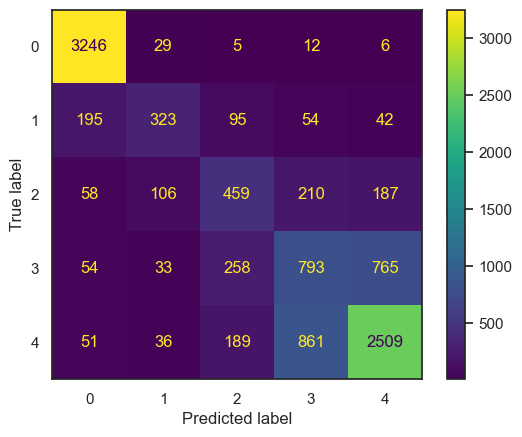

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9007    0.9842    0.9406      3298
           1     0.6129    0.4556    0.5227       709
           2     0.4563    0.4500    0.4531      1020
           3     0.4109    0.4167    0.4138      1903
           4     0.7150    0.6882    0.7013      3646

    accuracy                         0.6931     10576
   macro avg     0.6191    0.5989    0.6063     10576
weighted avg     0.6864    0.6931    0.6883     10576

Saved report for ResNet fold 3
Bootstrapped Macro F1: 0.6063
95% CI: (0.5952, 0.6174)
Started for fold 4


2025-09-18 10:22:46.840790: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 10:37:57.704293: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


837/837 [==============================] - 10s 9ms/step - loss: 0.9885 - sparse_categorical_accuracy: 0.6999


2025-09-18 10:38:07.698105: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


837/837 [==============================] - 7s 6ms/step


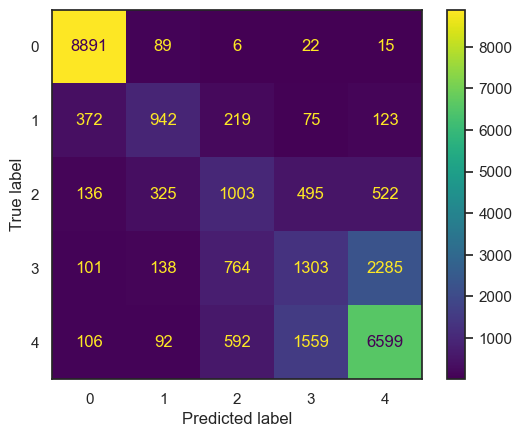

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9256    0.9854    0.9545      9023
           1     0.5939    0.5442    0.5680      1731
           2     0.3882    0.4043    0.3961      2481
           3     0.3772    0.2838    0.3239      4591
           4     0.6914    0.7375    0.7137      8948

    accuracy                         0.6999     26774
   macro avg     0.5953    0.5910    0.5912     26774
weighted avg     0.6821    0.6999    0.6892     26774

Saved report for ResNet fold 4
Bootstrapped Macro F1: 0.5913
95% CI: (0.5850, 0.5978)
Report for ResNet


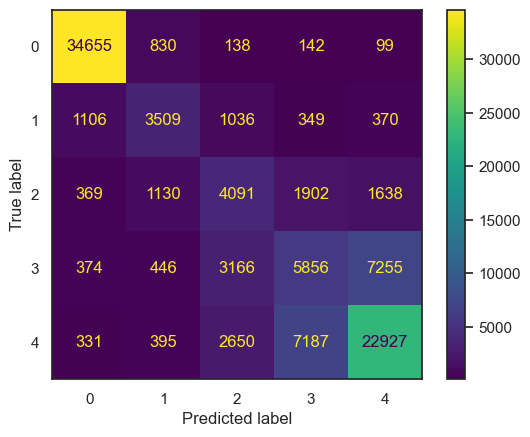

              precision    recall  f1-score   support

           0     0.9408    0.9663    0.9534     35864
           1     0.5561    0.5509    0.5535      6370
           2     0.3692    0.4481    0.4048      9130
           3     0.3794    0.3425    0.3600     17097
           4     0.7101    0.6846    0.6971     33490

    accuracy                         0.6968    101951
   macro avg     0.5911    0.5985    0.5938    101951
weighted avg     0.6956    0.6968    0.6956    101951



In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


# inilializes 5 folds for 5 fold cross validation
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All = []
predicted_labels_fcn_All = []
predicted_labels_resnet_All = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0


for train_idx, test_idx in kfolds.split(X_data):

        average_precisions = []
        PRauc_scores = []
        # the dataset is split into training and validation sets for the current fold
        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,25,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,25,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output", dim = 1)


        # initiliazes buffer size and batch size 
        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_rs, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_rs, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        # sets the learning rate of the Adam optimizer 
        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)

        # builds and trains the model
        model_wang_resnet = data_models.build_resnet_1d((X_train_fold.shape[1], X_train_fold.shape[2]), 64, 5) 
        model_wang_resnet.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['sparse_categorical_accuracy'])
        model_wang_resnet.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_wang_resnet.evaluate(X_test_t, Y_test_t)
        predictions_model_wang_resnet = model_wang_resnet.predict(X_test_t)
        y_pred_resnet = np.argmax(predictions_model_wang_resnet, axis=1) 
        ConfusionMatrixDisplay.from_predictions(Y_test_t, y_pred_resnet)
        plt.show()
        
        report_resnet = classification_report(Y_test_t, y_pred_resnet, digits=4)
        print(report_resnet)
        
        actual_labels_All.append(Y_test_t)

        predicted_labels_resnet_All.append(predictions_model_wang_resnet)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper = data_models.bootstrap_macro_f1(np.array(Y_test_t), np.array(y_pred_resnet))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_t, y_pred_resnet, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_t, y_pred_resnet, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_t, y_pred_resnet, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_t, y_pred_resnet, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_t,y_pred_resnet, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_t, y_pred_resnet, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
        targ_multi = enc.fit_transform(Y_test_fold.reshape(-1, 1))
        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(targ_multi[:, cl], predictions_model_wang_resnet[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            ap_score = average_precision_score(targ_multi[:, cl], predictions_model_wang_resnet[:, cl])
            average_precisions.append(ap_score)
            PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_preprocessing.expected_calibration_error(predictions_model_wang_resnet,Y_test_fold)
        ECE.append(ece_score)

        count = count + 1


# POPULATION
print("Report for ResNet")
y_pred_resnet = np.argmax(flatten(predicted_labels_resnet_All), axis=1) 
ConfusionMatrixDisplay.from_predictions(flatten(actual_labels_All), y_pred_resnet)
plt.show()


# calculating metric
print(classification_report(flatten(actual_labels_All), y_pred_resnet, digits = 4))

# saves the calculated metrics in txt file
with open("ResNet_5Fold_2h_CCEL.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

## Train FCN with 2 h vs 1 h vs 4 h vs 30 min ISL

In [ ]:
# creates time series sequences of 1 hour length, corresponding to 13 consecutive datapoints
X_data, Y_data = create_X_Y(df_min_max_scaled, "PtID", 13,1, 'h')

2025-09-17 15:40:31.047792: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-17 15:40:31.047810: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-17 15:40:31.459899: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:45:29.722732: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/330 [..............................] - ETA: 1:05

2025-09-17 15:45:31.507849: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


330/330 [==============================] - 1s 2ms/step


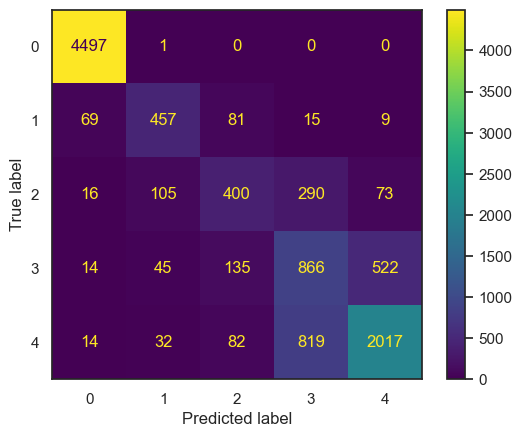

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9755    0.9998    0.9875      4498
           1     0.7141    0.7242    0.7191       631
           2     0.5731    0.4525    0.5057       884
           3     0.4352    0.5474    0.4849      1582
           4     0.7696    0.6805    0.7223      2964

    accuracy                         0.7801     10559
   macro avg     0.6935    0.6809    0.6839     10559
weighted avg     0.7874    0.7801    0.7814     10559

Saved report for FCN fold 1h 0
Bootstrapped Macro F1: 0.6836
95% CI: (0.6730, 0.6940)
Started for fold 1


2025-09-17 15:45:35.501509: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:50:10.841291: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/552 [..............................] - ETA: 2:01

2025-09-17 15:50:13.574252: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


552/552 [==============================] - 1s 2ms/step


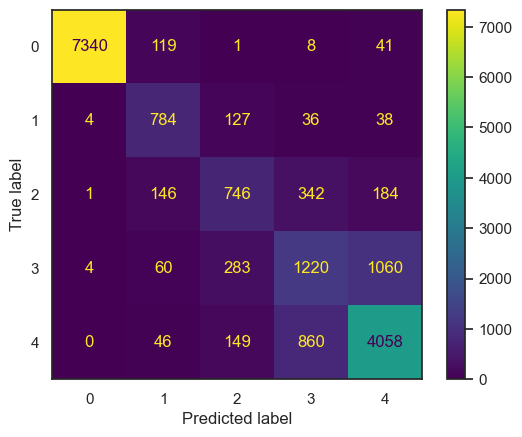

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9988    0.9775    0.9880      7509
           1     0.6788    0.7927    0.7313       989
           2     0.5712    0.5257    0.5475      1419
           3     0.4947    0.4644    0.4791      2627
           4     0.7541    0.7937    0.7734      5113

    accuracy                         0.8013     17657
   macro avg     0.6995    0.7108    0.7039     17657
weighted avg     0.8007    0.8013    0.8004     17657

Saved report for FCN fold 1h 1
Bootstrapped Macro F1: 0.7037
95% CI: (0.6954, 0.7120)
Started for fold 2


2025-09-17 15:50:19.635396: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:53:50.669290: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/1226 [..............................] - ETA: 3:46

2025-09-17 15:53:56.059153: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1226/1226 [==============================] - 2s 2ms/step


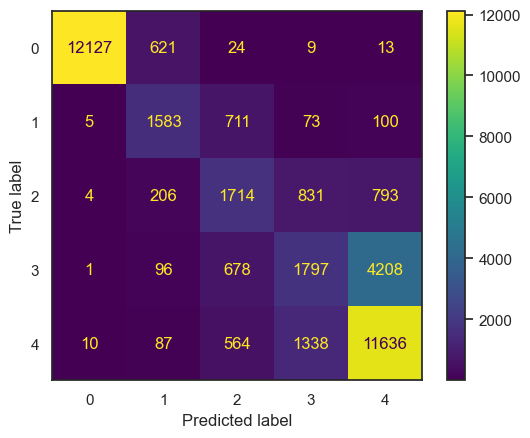

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9984    0.9479    0.9725     12794
           1     0.6105    0.6404    0.6251      2472
           2     0.4644    0.4831    0.4735      3548
           3     0.4439    0.2650    0.3319      6780
           4     0.6947    0.8534    0.7659     13635

    accuracy                         0.7356     39229
   macro avg     0.6424    0.6380    0.6338     39229
weighted avg     0.7242    0.7356    0.7229     39229

Saved report for FCN fold 1h 2
Bootstrapped Macro F1: 0.6339
95% CI: (0.6284, 0.6396)
Started for fold 3


2025-09-17 15:54:08.827749: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:58:50.611985: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/339 [..............................] - ETA: 1:02

2025-09-17 15:58:52.336609: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


339/339 [==============================] - 1s 2ms/step


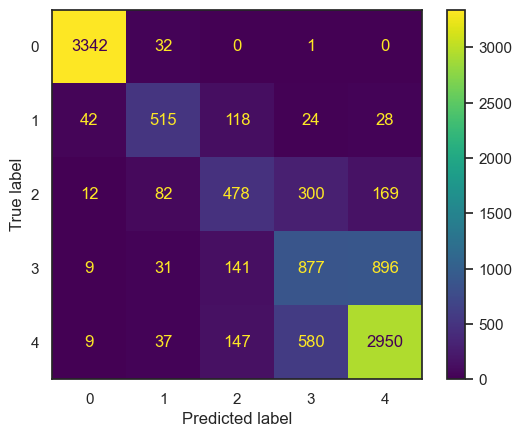

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9789    0.9902    0.9845      3375
           1     0.7389    0.7084    0.7233       727
           2     0.5407    0.4592    0.4966      1041
           3     0.4921    0.4488    0.4695      1954
           4     0.7297    0.7924    0.7597      3723

    accuracy                         0.7543     10820
   macro avg     0.6961    0.6798    0.6867     10820
weighted avg     0.7470    0.7543    0.7497     10820

Saved report for FCN fold 1h 3
Bootstrapped Macro F1: 0.6868
95% CI: (0.6765, 0.6960)
Started for fold 4


2025-09-17 15:58:56.206846: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 16:02:39.747591: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/875 [..............................] - ETA: 2:43

2025-09-17 16:02:43.447367: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


875/875 [==============================] - 2s 2ms/step


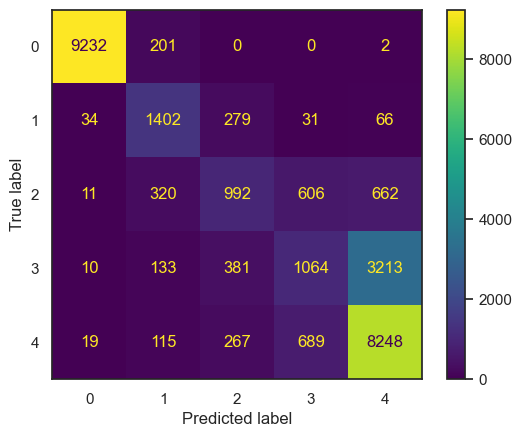

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9920    0.9785    0.9852      9435
           1     0.6458    0.7737    0.7040      1812
           2     0.5169    0.3829    0.4399      2591
           3     0.4452    0.2216    0.2959      4801
           4     0.6766    0.8833    0.7662      9338

    accuracy                         0.7484     27977
   macro avg     0.6553    0.6480    0.6383     27977
weighted avg     0.7265    0.7484    0.7251     27977

Saved report for FCN fold 1h 4
Bootstrapped Macro F1: 0.6382
95% CI: (0.6320, 0.6448)
Report for FCN


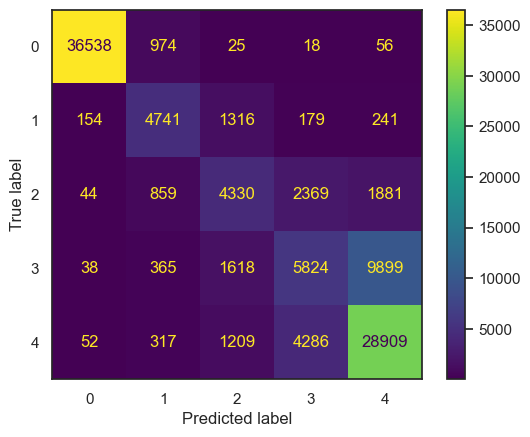

              precision    recall  f1-score   support

           0     0.9922    0.9715    0.9817     37611
           1     0.6534    0.7150    0.6828      6631
           2     0.5095    0.4566    0.4816      9483
           3     0.4595    0.3282    0.3829     17744
           4     0.7053    0.8314    0.7632     34773

    accuracy                         0.7562    106242
   macro avg     0.6640    0.6605    0.6584    106242
weighted avg     0.7451    0.7562    0.7469    106242



In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


# initiliazes 5 folds for 5 fold cross validation
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All_1h = []
predicted_labels_fcn_All_1h = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):

        average_precisions = []
        PRauc_scores = []

        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,13,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 13, dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 13, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,13,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f = 13,dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 13, dim = 1)


        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_rs, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_rs, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


         # sets the learning rate of the Adam optimizer 
        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)

        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['sparse_categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        ConfusionMatrixDisplay.from_predictions(Y_test_t, y_pred_fcn)
        plt.show()

        
        report_fcn = classification_report(Y_test_t, y_pred_fcn, digits=4)
        print(report_fcn)

        actual_labels_All_1h.append(Y_test_t)
        predicted_labels_fcn_All_1h.append(predictions_fcn)


        # Run bootstrapping
        mean_f1, ci_lower, ci_upper =data_models.bootstrap_macro_f1(np.array(Y_test_t), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_t, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_t, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_t, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_t,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
        targ_multi = enc.fit_transform(Y_test_fold.reshape(-1, 1))
        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(targ_multi[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            ap_score = average_precision_score(targ_multi[:, cl], predictions_fcn[:, cl])
            average_precisions.append(ap_score)
            PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)

        count = count + 1

# POPULATION
print("Report for FCN")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All_1h), axis=1) 
ConfusionMatrixDisplay.from_predictions(flatten(actual_labels_All_1h), y_pred_fcn)
plt.show()
# calculating metric
print(classification_report(flatten(actual_labels_All_1h), y_pred_fcn, digits = 4))


# Save everything to a single text file
with open("FCN_5Fold_1h_CCEL.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

In [ ]:
# creates time series sequences of 4 hour lenghts, corresponsing to 49 consecutive datapoints
X_data, Y_data = create_X_Y(df_min_max_scaled, "PtID", 49,4, 'h')

2025-09-17 21:10:23.418461: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-17 21:10:23.418492: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-17 21:10:24.145025: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 21:16:38.358487: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


295/295 [==============================] - 2s 6ms/step - loss: 0.5189 - sparse_categorical_accuracy: 0.7640


2025-09-17 21:16:40.689595: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


295/295 [==============================] - 1s 3ms/step


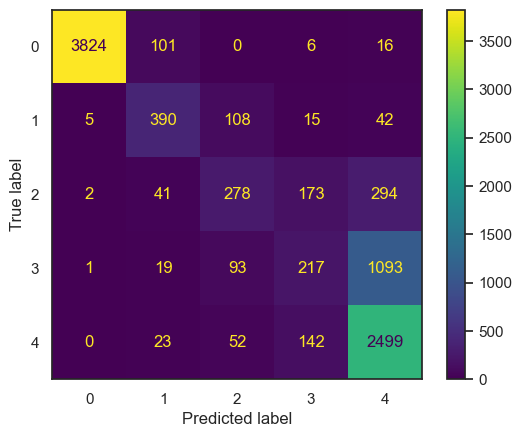

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9979    0.9688    0.9832      3947
           1     0.6794    0.6964    0.6878       560
           2     0.5235    0.3528    0.4215       788
           3     0.3924    0.1525    0.2196      1423
           4     0.6336    0.9201    0.7505      2716

    accuracy                         0.7640      9434
   macro avg     0.6454    0.6181    0.6125      9434
weighted avg     0.7432    0.7640    0.7366      9434

Saved report for FCN fold 4h 0
Bootstrapped Macro F1: 0.6125
95% CI: (0.5997, 0.6242)
Started for fold 1


2025-09-17 21:16:45.952703: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 21:22:37.539407: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


475/475 [==============================] - 3s 6ms/step - loss: 0.5399 - sparse_categorical_accuracy: 0.7688


2025-09-17 21:22:40.893551: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


475/475 [==============================] - 2s 3ms/step


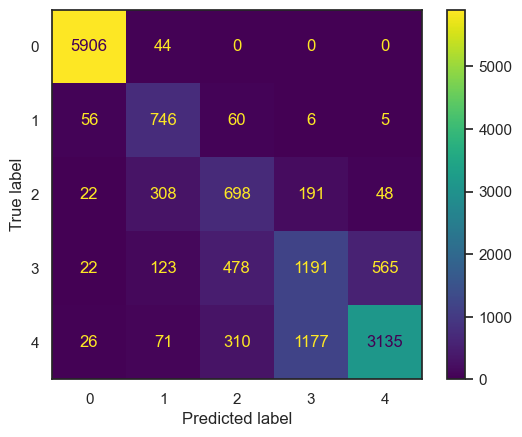

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9791    0.9926    0.9858      5950
           1     0.5774    0.8545    0.6891       873
           2     0.4515    0.5509    0.4963      1267
           3     0.4643    0.5006    0.4818      2379
           4     0.8353    0.6643    0.7401      4719

    accuracy                         0.7688     15188
   macro avg     0.6615    0.7126    0.6786     15188
weighted avg     0.7867    0.7688    0.7726     15188

Saved report for FCN fold 4h 1
Bootstrapped Macro F1: 0.6784
95% CI: (0.6694, 0.6874)
Started for fold 2


2025-09-17 21:22:48.522322: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 21:27:10.564470: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1103/1103 [==============================] - 7s 6ms/step - loss: 0.5900 - sparse_categorical_accuracy: 0.7390


2025-09-17 21:27:17.342398: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1103/1103 [==============================] - 3s 3ms/step


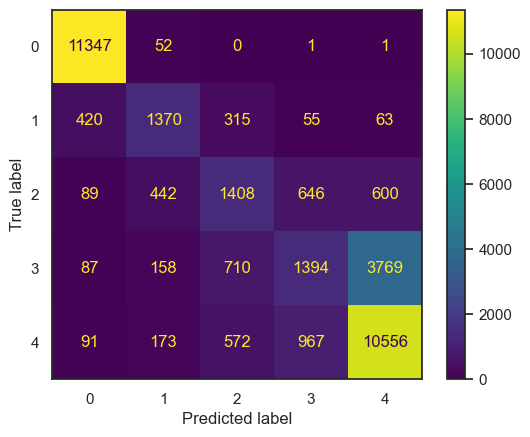

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9429    0.9953    0.9684     11401
           1     0.6241    0.6163    0.6202      2223
           2     0.4686    0.4421    0.4549      3185
           3     0.4551    0.2279    0.3037      6118
           4     0.7042    0.8541    0.7720     12359

    accuracy                         0.7390     35286
   macro avg     0.6390    0.6271    0.6238     35286
weighted avg     0.7118    0.7390    0.7161     35286

Saved report for FCN fold 4h 2
Bootstrapped Macro F1: 0.6240
95% CI: (0.6181, 0.6296)
Started for fold 3


2025-09-17 21:27:34.210766: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 21:33:41.780644: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


316/316 [==============================] - 3s 6ms/step - loss: 0.5814 - sparse_categorical_accuracy: 0.7477


2025-09-17 21:33:44.411965: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


316/316 [==============================] - 1s 3ms/step


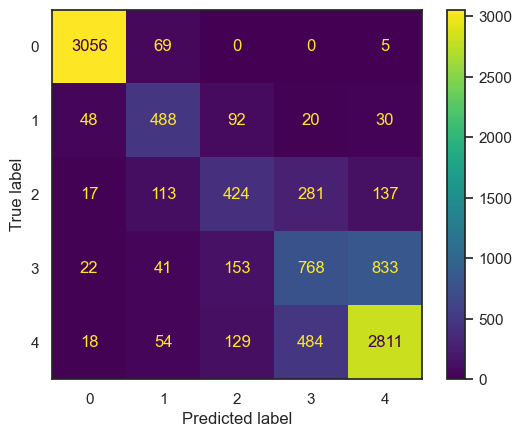

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9668    0.9764    0.9715      3130
           1     0.6379    0.7198    0.6764       678
           2     0.5313    0.4362    0.4791       972
           3     0.4945    0.4227    0.4558      1817
           4     0.7366    0.8041    0.7689      3496

    accuracy                         0.7477     10093
   macro avg     0.6734    0.6718    0.6703     10093
weighted avg     0.7380    0.7477    0.7412     10093

Saved report for FCN fold 4h 3
Bootstrapped Macro F1: 0.6702
95% CI: (0.6592, 0.6809)
Started for fold 4


2025-09-17 21:33:49.984997: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 21:38:53.524546: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


767/767 [==============================] - 5s 6ms/step - loss: 0.6110 - sparse_categorical_accuracy: 0.7398


2025-09-17 21:38:58.271074: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


767/767 [==============================] - 2s 3ms/step


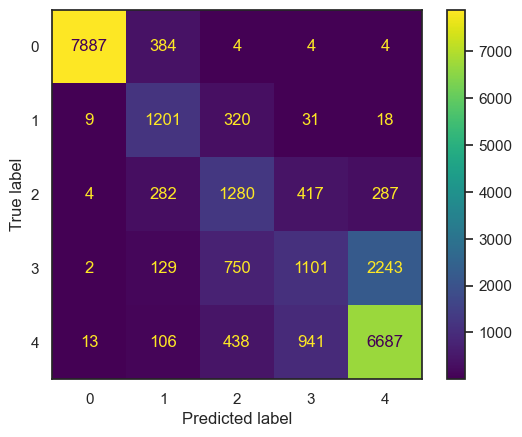

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9965    0.9522    0.9738      8283
           1     0.5714    0.7606    0.6525      1579
           2     0.4585    0.5639    0.5057      2270
           3     0.4415    0.2606    0.3277      4225
           4     0.7238    0.8170    0.7676      8185

    accuracy                         0.7398     24542
   macro avg     0.6383    0.6708    0.6455     24542
weighted avg     0.7329    0.7398    0.7298     24542

Saved report for FCN fold 4h 4
Bootstrapped Macro F1: 0.6453
95% CI: (0.6390, 0.6523)
Report for FCN


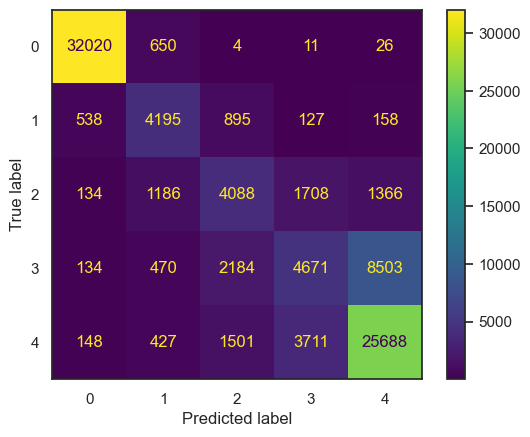

              precision    recall  f1-score   support

           0     0.9711    0.9789    0.9750     32711
           1     0.6055    0.7095    0.6534      5913
           2     0.4714    0.4820    0.4766      8482
           3     0.4567    0.2926    0.3567     15962
           4     0.7187    0.8161    0.7643     31475

    accuracy                         0.7474     94543
   macro avg     0.6447    0.6558    0.6452     94543
weighted avg     0.7325    0.7474    0.7356     94543



In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


# intiliazes 5 folds 
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All_4h = []
predicted_labels_fcn_All_4h = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):

        average_precisions = []
        PRauc_scores = []

        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,49,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 49, dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 49, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,49,2)
        X_test_fold = data_preprocessing.latten_data(X_test_fold, modus = "input", shape_f = 49,dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 49, dim = 1)


        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_rs, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_rs, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

         # sets the learning rate of the Adam optimizer 
        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)

        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['sparse_categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        ConfusionMatrixDisplay.from_predictions(Y_test_t, y_pred_fcn)
        plt.show()
        
        report_fcn = classification_report(Y_test_t, y_pred_fcn, digits=4)
        print(report_fcn)


        actual_labels_All_4h.append(Y_test_t)
        predicted_labels_fcn_All_4h.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper =data_models.bootstrap_macro_f1(np.array(Y_test_t), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_t, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_t, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_t, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_t,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
        targ_multi = enc.fit_transform(Y_test_fold.reshape(-1, 1))
        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(targ_multi[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            ap_score = average_precision_score(targ_multi[:, cl], predictions_fcn[:, cl])
            average_precisions.append(ap_score)
            PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)

        count = count + 1

# POPULATION
print("Report for FCN")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All_4h), axis=1) 
ConfusionMatrixDisplay.from_predictions(flatten(actual_labels_All_4h), y_pred_fcn)
plt.show()
# calculating metric
print(classification_report(flatten(actual_labels_All_4h), y_pred_fcn, digits=4))


# Save everything to a single text file
with open("FCN_5Fold_4h_CCEL.txt", "w") as f:
    
    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

In [ ]:
# creates time series sequences of 30 minutes, corresponding to 7 consecutive datapoints
X_data, Y_data = create_X_Y(df_min_max_scaled, "PtID", 7, 30, 'm')

2025-09-17 15:15:14.815861: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-17 15:15:14.815880: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-17 15:15:15.237163: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:20:04.837432: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/325 [..............................] - ETA: 1:00

2025-09-17 15:20:06.545420: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 1s 2ms/step


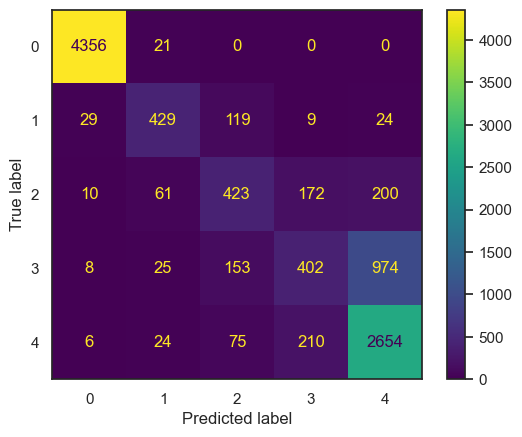

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9880    0.9952    0.9916      4377
           1     0.7661    0.7033    0.7333       610
           2     0.5494    0.4885    0.5171       866
           3     0.5069    0.2574    0.3414      1562
           4     0.6890    0.8939    0.7782      2969

    accuracy                         0.7958     10384
   macro avg     0.6999    0.6676    0.6723     10384
weighted avg     0.7805    0.7958    0.7780     10384

Saved report for FCN fold 30min 0
Bootstrapped Macro F1: 0.6722
95% CI: (0.6613, 0.6837)
Started for fold 1


2025-09-17 15:20:10.274741: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:24:42.991530: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/542 [..............................] - ETA: 1:46

2025-09-17 15:24:45.606601: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 1s 2ms/step


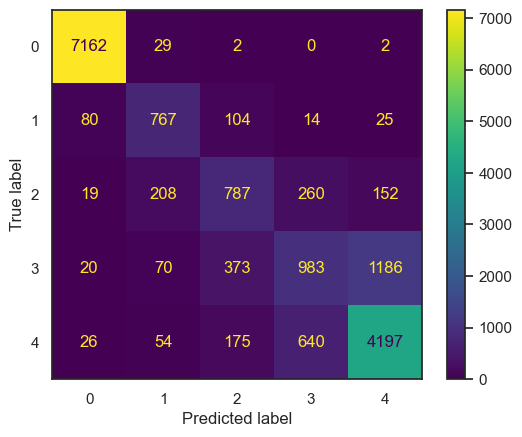

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9802    0.9954    0.9877      7195
           1     0.6800    0.7747    0.7243       990
           2     0.5461    0.5519    0.5490      1426
           3     0.5182    0.3735    0.4341      2632
           4     0.7546    0.8242    0.7879      5092

    accuracy                         0.8016     17335
   macro avg     0.6958    0.7040    0.6966     17335
weighted avg     0.7909    0.8016    0.7938     17335

Saved report for FCN fold 30min 1
Bootstrapped Macro F1: 0.6966
95% CI: (0.6881, 0.7058)
Started for fold 2


2025-09-17 15:24:51.441092: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:28:17.685893: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/1258 [..............................] - ETA: 4:24

2025-09-17 15:28:23.056280: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 2s 2ms/step


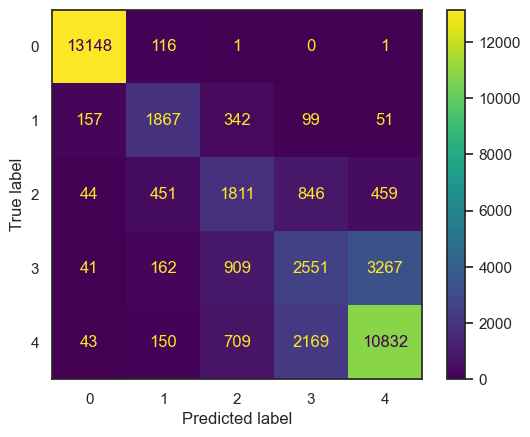

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9788    0.9911    0.9849     13266
           1     0.6799    0.7421    0.7096      2516
           2     0.4801    0.5015    0.4906      3611
           3     0.4503    0.3681    0.4051      6930
           4     0.7414    0.7791    0.7598     13903

    accuracy                         0.7510     40226
   macro avg     0.6661    0.6764    0.6700     40226
weighted avg     0.7422    0.7510    0.7456     40226

Saved report for FCN fold 30min 2
Bootstrapped Macro F1: 0.6702
95% CI: (0.6652, 0.6757)
Started for fold 3


2025-09-17 15:28:36.243876: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:33:23.005622: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/378 [..............................] - ETA: 1:13

2025-09-17 15:33:24.967066: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 1s 2ms/step


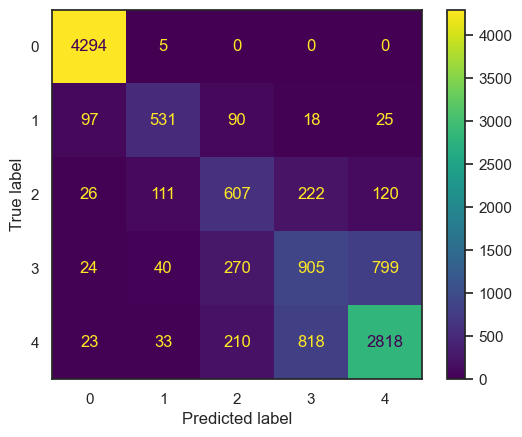

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9619    0.9988    0.9800      4299
           1     0.7375    0.6978    0.7171       761
           2     0.5157    0.5589    0.5365      1086
           3     0.4610    0.4441    0.4524      2038
           4     0.7491    0.7222    0.7354      3902

    accuracy                         0.7575     12086
   macro avg     0.6850    0.6844    0.6843     12086
weighted avg     0.7545    0.7575    0.7557     12086

Saved report for FCN fold 30min 3
Bootstrapped Macro F1: 0.6845
95% CI: (0.6749, 0.6941)
Started for fold 4


2025-09-17 15:33:29.314753: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 15:37:24.381079: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/892 [..............................] - ETA: 2:53

2025-09-17 15:37:28.312226: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 2s 2ms/step


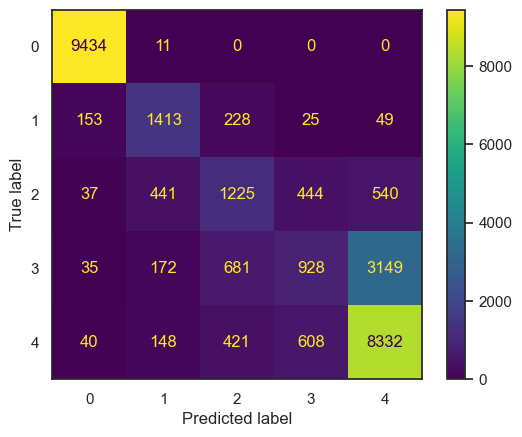

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9727    0.9988    0.9856      9445
           1     0.6467    0.7564    0.6973      1868
           2     0.4795    0.4559    0.4674      2687
           3     0.4628    0.1869    0.2663      4965
           4     0.6903    0.8726    0.7708      9549

    accuracy                         0.7481     28514
   macro avg     0.6504    0.6541    0.6375     28514
weighted avg     0.7215    0.7481    0.7207     28514

Saved report for FCN fold 30min 4
Bootstrapped Macro F1: 0.6376
95% CI: (0.6314, 0.6438)
Report for FCN


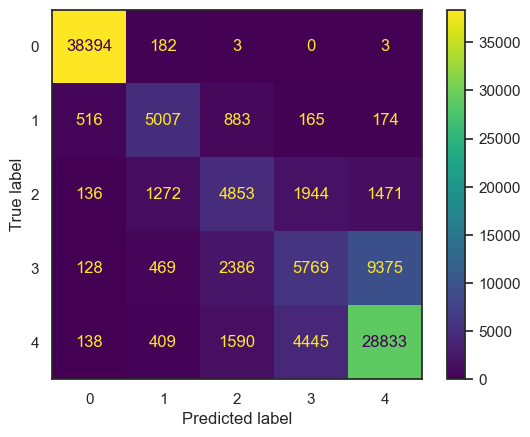

              precision    recall  f1-score   support

           0     0.9766    0.9951    0.9858     38582
           1     0.6822    0.7423    0.7110      6745
           2     0.4995    0.5016    0.5005      9676
           3     0.4681    0.3183    0.3789     18127
           4     0.7234    0.8141    0.7661     35415

    accuracy                         0.7633    108545
   macro avg     0.6700    0.6743    0.6685    108545
weighted avg     0.7483    0.7633    0.7524    108545



In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


# initializes 5 folds
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for accuracy and variables of each fold which are stored
actual_labels_All_30min = []
predicted_labels_fcn_All_30min = []

lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []


count = 0

for train_idx, test_idx in kfolds.split(X_data):
        
        average_precisions = []
        PRauc_scores = []

        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)


        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_rs, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_rs, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

         # sets the learning rate of the Adam optimizer 
        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)

        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['sparse_categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        ConfusionMatrixDisplay.from_predictions(Y_test_t, y_pred_fcn)
        plt.show()
        
        report_fcn = classification_report(Y_test_t, y_pred_fcn, digits=4)
        print(report_fcn)


        actual_labels_All_30min.append(Y_test_t)
        predicted_labels_fcn_All_30min.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper =data_models.bootstrap_macro_f1(np.array(Y_test_t), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_t, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_t, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_t, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_t,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
        targ_multi = enc.fit_transform(Y_test_fold.reshape(-1, 1))
        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(targ_multi[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            ap_score = average_precision_score(targ_multi[:, cl], predictions_fcn[:, cl])
            average_precisions.append(ap_score)
            PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)

        count = count + 1

# POPULATION
print("Report for FCN")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All_30min), axis=1) 
ConfusionMatrixDisplay.from_predictions(flatten(actual_labels_All_30min), y_pred_fcn)
plt.show()
# calculating metric
print(classification_report(flatten(actual_labels_All_30min), y_pred_fcn, digits=4))


# Save everything to a single text file
with open("FCN_5Fold_30min_CCEL.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

# Train FCN with 30 min ISL with class weights vs focal loss vs undersampling

In [ ]:
# creates time series sequences of 1 hour length, corresponding to 13 consecutive datapoints
X_data, Y_data = create_X_Y(df_min_max_scaled, "PtID", 13,1, 'h')

2025-09-18 00:19:56.811683: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-18 00:19:56.811725: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-18 00:19:57.495788: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:27:09.264228: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/325 [..............................] - ETA: 1:11

2025-09-18 00:27:11.419795: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 1s 2ms/step


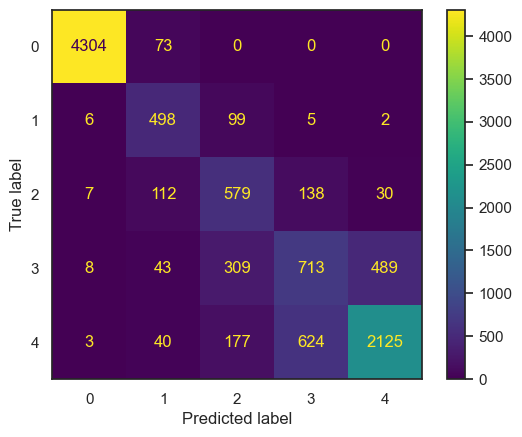

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9945    0.9833    0.9889      4377
           1     0.6501    0.8164    0.7238       610
           2     0.4974    0.6686    0.5704       866
           3     0.4818    0.4565    0.4688      1562
           4     0.8031    0.7157    0.7569      2969

    accuracy                         0.7915     10384
   macro avg     0.6854    0.7281    0.7018     10384
weighted avg     0.8009    0.7915    0.7938     10384

Saved report for FCN fold 30min weight 0
Bootstrapped Macro F1: 0.7017
95% CI: (0.6916, 0.7120)
Started for fold 1


2025-09-18 00:27:16.170738: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:31:54.792828: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/542 [..............................] - ETA: 1:56

2025-09-18 00:31:57.464912: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 1s 2ms/step


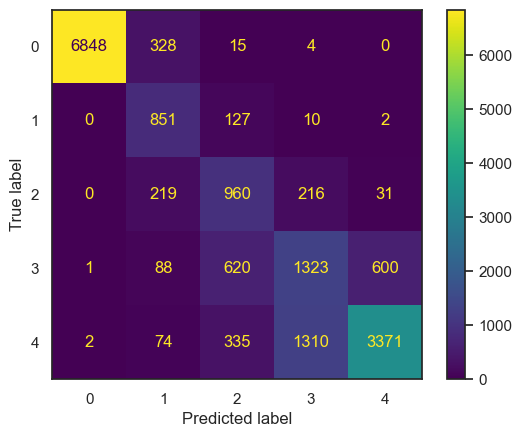

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9996    0.9518    0.9751      7195
           1     0.5455    0.8596    0.6675       990
           2     0.4667    0.6732    0.5512      1426
           3     0.4621    0.5027    0.4815      2632
           4     0.8419    0.6620    0.7412      5092

    accuracy                         0.7703     17335
   macro avg     0.6632    0.7299    0.6833     17335
weighted avg     0.8019    0.7703    0.7790     17335

Saved report for FCN fold 30min weight 1
Bootstrapped Macro F1: 0.6833
95% CI: (0.6755, 0.6911)
Started for fold 2


2025-09-18 00:32:03.529917: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:35:35.529360: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  21/1258 [..............................] - ETA: 3s  

2025-09-18 00:35:40.848709: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 2s 2ms/step


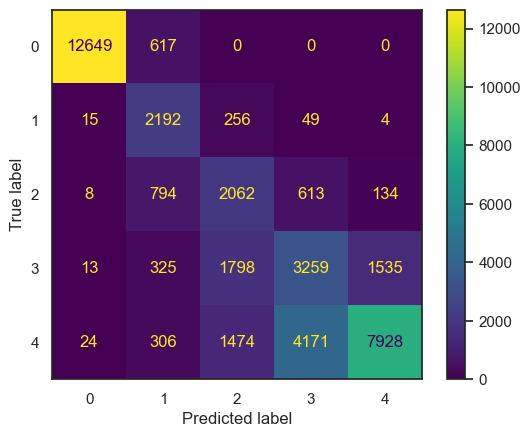

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9953    0.9535    0.9739     13266
           1     0.5177    0.8712    0.6495      2516
           2     0.3689    0.5710    0.4482      3611
           3     0.4027    0.4703    0.4339      6930
           4     0.8257    0.5702    0.6746     13903

    accuracy                         0.6983     40226
   macro avg     0.6221    0.6873    0.6360     40226
weighted avg     0.7485    0.6983    0.7100     40226

Saved report for FCN fold 30min weight 2
Bootstrapped Macro F1: 0.6360
95% CI: (0.6309, 0.6412)
Started for fold 3


2025-09-18 00:35:54.268760: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:40:41.852361: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/378 [..............................] - ETA: 1:16

2025-09-18 00:40:43.768438: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 1s 2ms/step


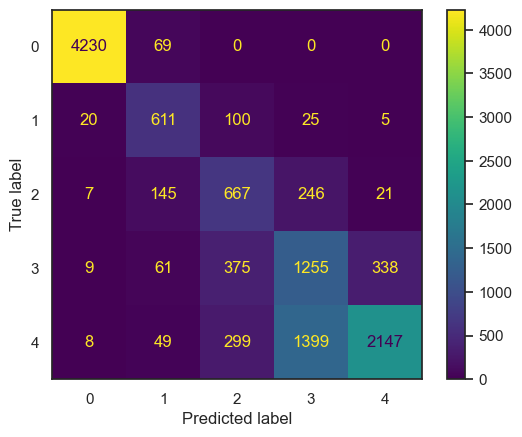

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9897    0.9839    0.9868      4299
           1     0.6535    0.8029    0.7205       761
           2     0.4629    0.6142    0.5279      1086
           3     0.4291    0.6158    0.5057      2038
           4     0.8550    0.5502    0.6696      3902

    accuracy                         0.7372     12086
   macro avg     0.6780    0.7134    0.6821     12086
weighted avg     0.7832    0.7372    0.7453     12086

Saved report for FCN fold 30min weight 3
Bootstrapped Macro F1: 0.6824
95% CI: (0.6739, 0.6914)
Started for fold 4


2025-09-18 00:40:48.201328: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:44:47.337221: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/892 [..............................] - ETA: 2:57

2025-09-18 00:44:51.300235: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 2s 2ms/step


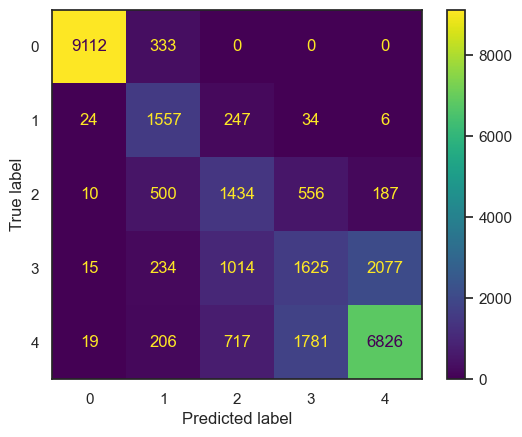

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9926    0.9647    0.9785      9445
           1     0.5502    0.8335    0.6628      1868
           2     0.4203    0.5337    0.4702      2687
           3     0.4067    0.3273    0.3627      4965
           4     0.7504    0.7148    0.7322      9549

    accuracy                         0.7208     28514
   macro avg     0.6240    0.6748    0.6413     28514
weighted avg     0.7266    0.7208    0.7202     28514

Saved report for FCN fold 30min weight 4
Bootstrapped Macro F1: 0.6415
95% CI: (0.6359, 0.6474)
Report for FCN


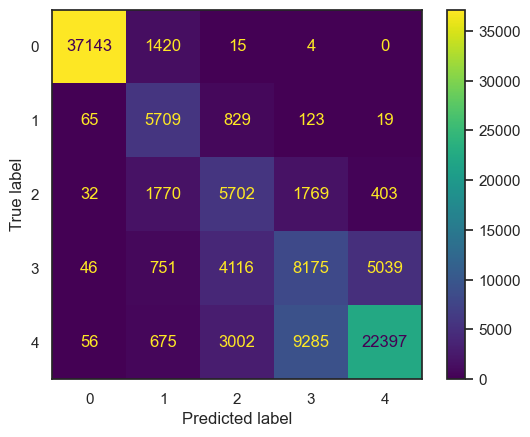

              precision    recall  f1-score   support

           0     0.9947    0.9627    0.9784     38582
           1     0.5529    0.8464    0.6689      6745
           2     0.4173    0.5893    0.4886      9676
           3     0.4223    0.4510    0.4362     18127
           4     0.8040    0.6324    0.7079     35415

    accuracy                         0.7290    108545
   macro avg     0.6382    0.6964    0.6560    108545
weighted avg     0.7580    0.7290    0.7367    108545



In [ ]:
# testing categorical cross entropy loss with class weights

# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


# initializes 5 folds 
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All_30min_weight = []
predicted_labels_fcn_All_30min_weight = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):
        average_precisions = []
        PRauc_scores = []

        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)


        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_rs, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_rs, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

         # sets the learning rate of the Adam optimizer 
        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)

        # estimating distribution of classes
        labels_df = pd.DataFrame(Y_test_rs, columns = ['label'])
        class_occurences = np.bincount(labels_df['label'])
        total = class_occurences.sum()
        number_classes = len(class_occurences)

        # assigning weights for classes, weight for last class stays 1, since its occurance is the highest
        weight_for_0 = (1/class_occurences[0]) * (total/number_classes)
        weight_for_1 = (1/class_occurences[1]) * (total/number_classes)
        weight_for_2 = (1/class_occurences[2]) * (total/number_classes)
        weight_for_3 = (1/class_occurences[3]) * (total/number_classes)
        weight_for_4 = (1/class_occurences[4]) * (total/number_classes)

        class_weights = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3, 4: weight_for_4}


        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['sparse_categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0, class_weight = class_weights)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        ConfusionMatrixDisplay.from_predictions(Y_test_t, y_pred_fcn)
        plt.show()

        report_fcn = classification_report(Y_test_t, y_pred_fcn, digits=4)
        print(report_fcn)

        actual_labels_All_30min_weight.append(Y_test_t)
        predicted_labels_fcn_All_30min_weight.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper =data_models.bootstrap_macro_f1(np.array(Y_test_t), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_t, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_t, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_t, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_t,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
        targ_multi = enc.fit_transform(Y_test_fold.reshape(-1, 1))
        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(targ_multi[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            ap_score = average_precision_score(targ_multi[:, cl], predictions_fcn[:, cl])
            average_precisions.append(ap_score)
            PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)

        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)

        count = count + 1

# POPULATION
print("Report for FCN")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All_30min_weight), axis=1) 
ConfusionMatrixDisplay.from_predictions(flatten(actual_labels_All_30min_weight), y_pred_fcn)
plt.show()
# calculating metric
print(classification_report(flatten(actual_labels_All_30min), y_pred_fcn,digits = 4))

# Save everything to a single text file
with open("FCN_5Fold_30min_CCEL_class_weights.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

2025-09-17 23:21:06.773717: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-17 23:21:06.773746: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-17 23:21:07.377411: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 23:26:37.392255: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 25/325 [=>............................] - ETA: 0s 

2025-09-17 23:26:39.133803: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 1s 2ms/step


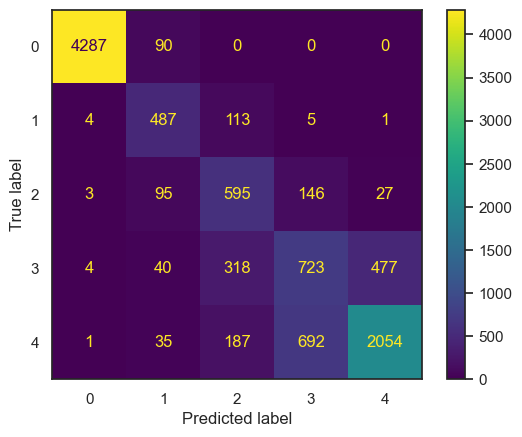

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9972    0.9794    0.9882      4377
           1     0.6519    0.7984    0.7178       610
           2     0.4905    0.6871    0.5724       866
           3     0.4617    0.4629    0.4623      1562
           4     0.8027    0.6918    0.7431      2969

    accuracy                         0.7845     10384
   macro avg     0.6808    0.7239    0.6968     10384
weighted avg     0.7985    0.7845    0.7885     10384

Saved report for FCN fold 30min weight focal 0
Bootstrapped Macro F1: 0.6967
95% CI: (0.6861, 0.7066)
Started for fold 1


2025-09-17 23:26:42.940484: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 23:31:33.265449: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 52/542 [=>............................] - ETA: 0s

2025-09-17 23:31:35.735397: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 1s 2ms/step


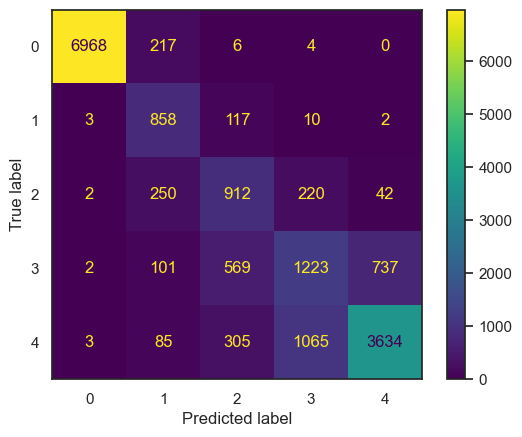

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9986    0.9685    0.9833      7195
           1     0.5678    0.8667    0.6861       990
           2     0.4777    0.6396    0.5469      1426
           3     0.4849    0.4647    0.4746      2632
           4     0.8231    0.7137    0.7645      5092

    accuracy                         0.7843     17335
   macro avg     0.6704    0.7306    0.6911     17335
weighted avg     0.8016    0.7843    0.7889     17335

Saved report for FCN fold 30min weight focal 1
Bootstrapped Macro F1: 0.6911
95% CI: (0.6836, 0.6990)
Started for fold 2


2025-09-17 23:31:41.244536: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 23:35:17.451278: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/1258 [..............................] - ETA: 4:12

2025-09-17 23:35:22.979885: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 2s 2ms/step


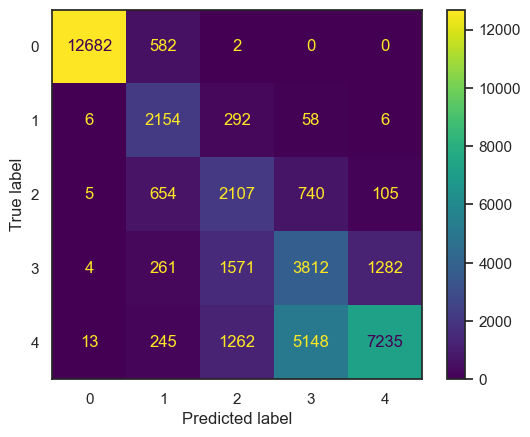

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9978    0.9560    0.9764     13266
           1     0.5529    0.8561    0.6719      2516
           2     0.4026    0.5835    0.4764      3611
           3     0.3907    0.5501    0.4569      6930
           4     0.8385    0.5204    0.6422     13903

    accuracy                         0.6958     40226
   macro avg     0.6365    0.6932    0.6448     40226
weighted avg     0.7569    0.6958    0.7075     40226

Saved report for FCN fold 30min weight focal 2
Bootstrapped Macro F1: 0.6448
95% CI: (0.6398, 0.6505)
Started for fold 3


2025-09-17 23:35:35.948301: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 23:40:53.105768: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 20/378 [>.............................] - ETA: 1s 

2025-09-17 23:40:55.262529: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 1s 2ms/step


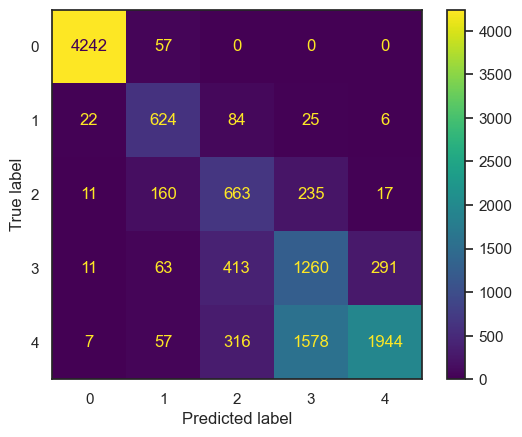

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9881    0.9867    0.9874      4299
           1     0.6493    0.8200    0.7247       761
           2     0.4492    0.6105    0.5176      1086
           3     0.4067    0.6183    0.4907      2038
           4     0.8609    0.4982    0.6312      3902

    accuracy                         0.7226     12086
   macro avg     0.6709    0.7067    0.6703     12086
weighted avg     0.7793    0.7226    0.7299     12086

Saved report for FCN fold 30min weight focal 3
Bootstrapped Macro F1: 0.6706
95% CI: (0.6614, 0.6796)
Started for fold 4


2025-09-17 23:40:59.605904: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 23:45:21.018229: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/892 [..............................] - ETA: 2:49

2025-09-17 23:45:24.948234: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 2s 2ms/step


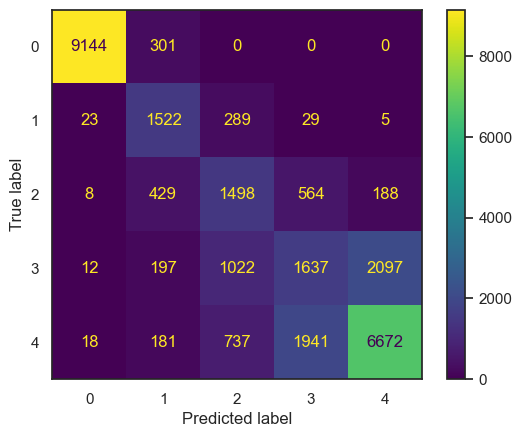

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9934    0.9681    0.9806      9445
           1     0.5787    0.8148    0.6767      1868
           2     0.4224    0.5575    0.4807      2687
           3     0.3925    0.3297    0.3584      4965
           4     0.7445    0.6987    0.7209      9549

    accuracy                         0.7180     28514
   macro avg     0.6263    0.6738    0.6434     28514
weighted avg     0.7244    0.7180    0.7183     28514

Saved report for FCN fold 30min weight focal 4
Bootstrapped Macro F1: 0.6436
95% CI: (0.6375, 0.6495)
Report for FCN


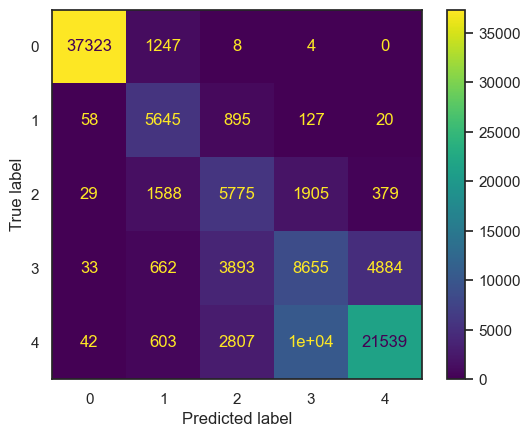

              precision    recall  f1-score   support

           0     0.9957    0.9674    0.9813     38582
           1     0.5793    0.8369    0.6847      6745
           2     0.4317    0.5968    0.5010      9676
           3     0.4099    0.4775    0.4411     18127
           4     0.8030    0.6082    0.6922     35415

    accuracy                         0.7272    108545
   macro avg     0.6439    0.6974    0.6600    108545
weighted avg     0.7588    0.7272    0.7355    108545



In [ ]:
# testing focal loss with weights 

# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# initializes 5 folds
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All_30min_weight_focal = []
predicted_labels_fcn_All_30min_weight_focal = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):
        average_precisions = []
        PRauc_scores = []
        
        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.latten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X7,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)


        Y_train_encoded = to_categorical(Y_train_fold)
        Y_test_encoded = to_categorical(Y_test_fold)

        # for class weights 
        Y_test_weights = Y_test_fold.reshape(-1).astype('int32')

        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
        focloss = tf.keras.losses.CategoricalFocalCrossentropy()
        
        # estimating distribution of classes
        labels_df = pd.DataFrame(Y_test_weights, columns = ['label'])
        class_occurences = np.bincount(labels_df['label'])
        total = class_occurences.sum()
        number_classes = len(class_occurences)

        # assigning weights for classes, weight for last class stays 1, since its occurance is the highest
        weight_for_0 = (1/class_occurences[0]) * (total/number_classes)
        weight_for_1 = (1/class_occurences[1]) * (total/number_classes)
        weight_for_2 = (1/class_occurences[2]) * (total/number_classes)
        weight_for_3 = (1/class_occurences[3]) * (total/number_classes)
        weight_for_4 = (1/class_occurences[4]) * (total/number_classes)

        class_weights = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3, 4: weight_for_4}


        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=['categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0, class_weight = class_weights)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        y_true_labels = np.argmax(Y_test_t, axis=1)
        ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
        plt.show()
        
        report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
        print(report_fcn)

        actual_labels_All_30min_weight_focal.append(Y_test_t)
        predicted_labels_fcn_All_30min_weight_focal.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper =data_models.bootstrap_macro_f1(np.array(Y_test_rs), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
                f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
                sorted_indices = np.argsort(f_rec)
                pr_auc_scores = auc(f_rec, f_pre)
                ap_score = average_precision_score(Y_test_t[:, cl], predictions_fcn[:, cl])
                average_precisions.append(ap_score)
                PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)

        count = count + 1


# POPULATION
print("Report for FCN")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All_30min_weight_focal), axis=1) 
y_true_labels = np.argmax(flatten(actual_labels_All_30min_weight_focal), axis=1)
ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
plt.show()

# calculating metric
print(classification_report(y_true_labels, y_pred_fcn, digits = 4))


with open("FCN_5Fold_30min_focal_class_weights.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

2025-09-17 23:45:35.056077: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-17 23:45:35.056097: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-17 23:45:35.519575: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 23:50:56.065121: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/325 [..............................] - ETA: 1:02

2025-09-17 23:50:57.808759: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 1s 2ms/step


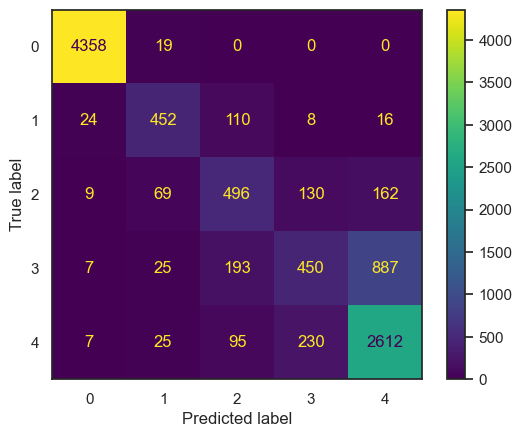

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9893    0.9957    0.9925      4377
           1     0.7661    0.7410    0.7533       610
           2     0.5548    0.5727    0.5636       866
           3     0.5501    0.2881    0.3782      1562
           4     0.7104    0.8798    0.7860      2969

    accuracy                         0.8059     10384
   macro avg     0.7141    0.6954    0.6947     10384
weighted avg     0.7941    0.8059    0.7912     10384

Saved report for FCN fold 30min focal no weights0
Bootstrapped Macro F1: 0.6948
95% CI: (0.6842, 0.7054)
Started for fold 1


2025-09-17 23:51:01.632001: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-17 23:55:55.856727: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/542 [..............................] - ETA: 1:45

2025-09-17 23:55:58.411184: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 1s 2ms/step


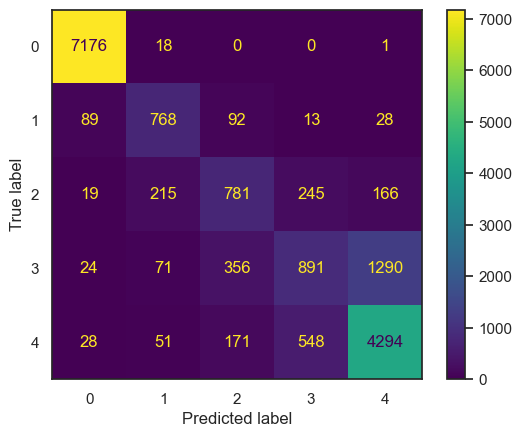

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9782    0.9974    0.9877      7195
           1     0.6839    0.7758    0.7269       990
           2     0.5579    0.5477    0.5527      1426
           3     0.5250    0.3385    0.4116      2632
           4     0.7430    0.8433    0.7900      5092

    accuracy                         0.8024     17335
   macro avg     0.6976    0.7005    0.6938     17335
weighted avg     0.7889    0.8024    0.7915     17335

Saved report for FCN fold 30min focal no weights1
Bootstrapped Macro F1: 0.6939
95% CI: (0.6860, 0.7026)
Started for fold 2


2025-09-17 23:56:04.156603: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/1258 [..............................] - ETA: 5:08 - loss: 0.0292 - categorical_accuracy: 0.9375

2025-09-17 23:59:44.807170: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/1258 [..............................] - ETA: 4:17

2025-09-17 23:59:49.968373: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 2s 2ms/step


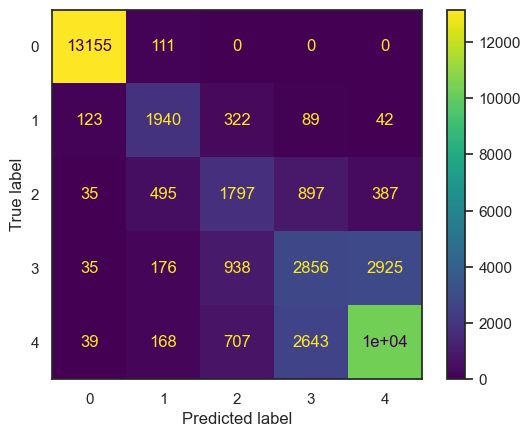

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9827    0.9916    0.9871     13266
           1     0.6713    0.7711    0.7177      2516
           2     0.4774    0.4976    0.4873      3611
           3     0.4404    0.4121    0.4258      6930
           4     0.7552    0.7442    0.7496     13903

    accuracy                         0.7481     40226
   macro avg     0.6654    0.6833    0.6735     40226
weighted avg     0.7458    0.7481    0.7466     40226

Saved report for FCN fold 30min focal no weights2
Bootstrapped Macro F1: 0.6737
95% CI: (0.6686, 0.6792)
Started for fold 3


2025-09-18 00:00:03.114441: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:05:06.148385: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 20/378 [>.............................] - ETA: 0s 

2025-09-18 00:05:08.073596: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 1s 2ms/step


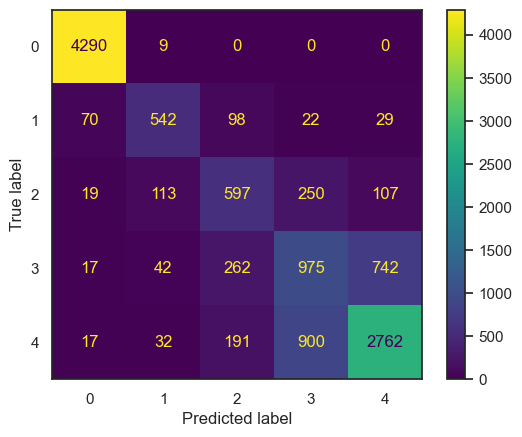

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9721    0.9979    0.9848      4299
           1     0.7344    0.7122    0.7231       761
           2     0.5200    0.5497    0.5345      1086
           3     0.4541    0.4784    0.4659      2038
           4     0.7588    0.7078    0.7324      3902

    accuracy                         0.7584     12086
   macro avg     0.6879    0.6892    0.6882     12086
weighted avg     0.7603    0.7584    0.7589     12086

Saved report for FCN fold 30min focal no weights3
Bootstrapped Macro F1: 0.6884
95% CI: (0.6786, 0.6980)
Started for fold 4


2025-09-18 00:05:12.290743: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:09:27.485446: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/892 [..............................] - ETA: 2:54

2025-09-18 00:09:31.613469: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 2s 2ms/step


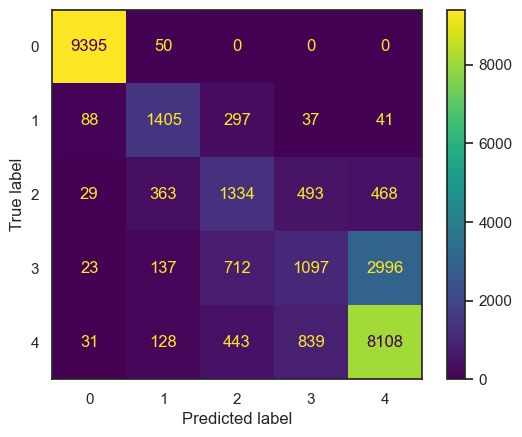

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9821    0.9947    0.9884      9445
           1     0.6745    0.7521    0.7112      1868
           2     0.4788    0.4965    0.4875      2687
           3     0.4448    0.2209    0.2952      4965
           4     0.6982    0.8491    0.7663      9549

    accuracy                         0.7484     28514
   macro avg     0.6557    0.6627    0.6497     28514
weighted avg     0.7259    0.7484    0.7279     28514

Saved report for FCN fold 30min focal no weights4
Bootstrapped Macro F1: 0.6498
95% CI: (0.6441, 0.6562)
Report for FCN


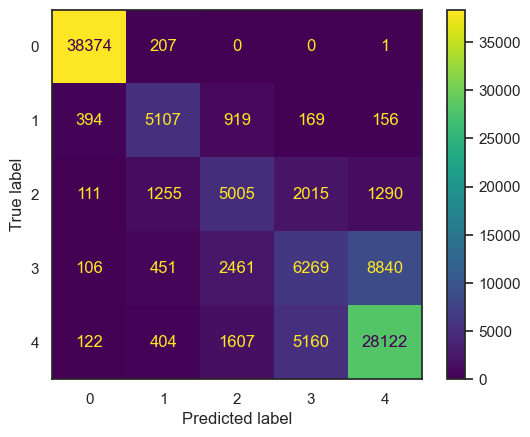

              precision    recall  f1-score   support

           0     0.9813    0.9946    0.9879     38582
           1     0.6879    0.7572    0.7209      6745
           2     0.5009    0.5173    0.5089      9676
           3     0.4605    0.3458    0.3950     18127
           4     0.7322    0.7941    0.7619     35415

    accuracy                         0.7635    108545
   macro avg     0.6725    0.6818    0.6749    108545
weighted avg     0.7520    0.7635    0.7558    108545



In [ ]:
# testing default focal loss

# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# initializes 5 folds
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All_30min_focal = []
predicted_labels_fcn_All_30min_focal = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):
        average_precisions = []
        PRauc_scores = []
        

        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)


        Y_train_encoded = to_categorical(Y_train_fold)
        Y_test_encoded = to_categorical(Y_test_fold)

        # for class weights 
        Y_test_weights = Y_test_fold.reshape(-1).astype('int32')

        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
        focloss = tf.keras.losses.CategoricalFocalCrossentropy()
        
      

        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=['categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        y_true_labels = np.argmax(Y_test_t, axis=1)
        ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
        plt.show()
        
        report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
        print(report_fcn)

        actual_labels_All_30min_focal.append(Y_test_t)
        predicted_labels_fcn_All_30min_focal.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper =data_models.bootstrap_macro_f1(np.array(Y_test_rs), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
                f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
                sorted_indices = np.argsort(f_rec)
                pr_auc_scores = auc(f_rec, f_pre)
                ap_score = average_precision_score(Y_test_t[:, cl], predictions_fcn[:, cl])
                average_precisions.append(ap_score)
                PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)

        count = count + 1

# POPULATION
print("Report for FCN")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All_30min_focal), axis=1) 
y_true_labels = np.argmax(flatten(actual_labels_All_30min_focal), axis=1)
ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
plt.show()

# calculating metric
print(classification_report(y_true_labels, y_pred_fcn, digits = 4))

# saves calculated metrics to a txt files
with open("FCN_5Fold_30min_focal.txt", "w") as f:
    actual_labels_All_under = []
    predicted_labels_fcn_under = []

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

2025-09-18 00:09:44.656678: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-18 00:09:44.656722: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-18 00:09:45.336196: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:11:46.977022: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 2s 5ms/step - loss: 0.5374 - sparse_categorical_accuracy: 0.7609


2025-09-18 00:11:49.115538: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 1s 3ms/step


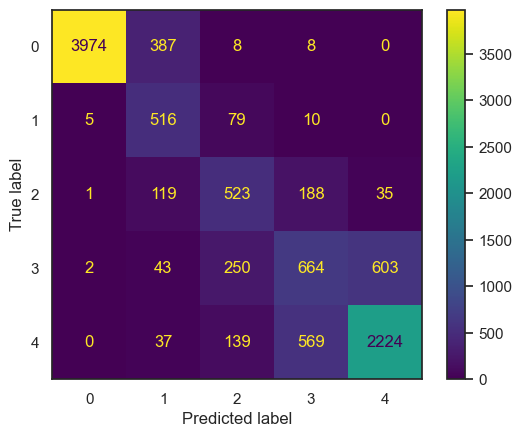

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9980    0.9079    0.9508      4377
           1     0.4682    0.8459    0.6028       610
           2     0.5235    0.6039    0.5609       866
           3     0.4614    0.4251    0.4425      1562
           4     0.7771    0.7491    0.7628      2969

    accuracy                         0.7609     10384
   macro avg     0.6457    0.7064    0.6640     10384
weighted avg     0.7834    0.7609    0.7676     10384

Saved report for FCN fold 30min under 0
Bootstrapped Macro F1: 0.6640
95% CI: (0.6533, 0.6745)
Started for fold 1


2025-09-18 00:11:54.554555: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:13:44.600843: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 3s 5ms/step - loss: 0.5402 - sparse_categorical_accuracy: 0.7678


2025-09-18 00:13:47.777050: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 2s 2ms/step


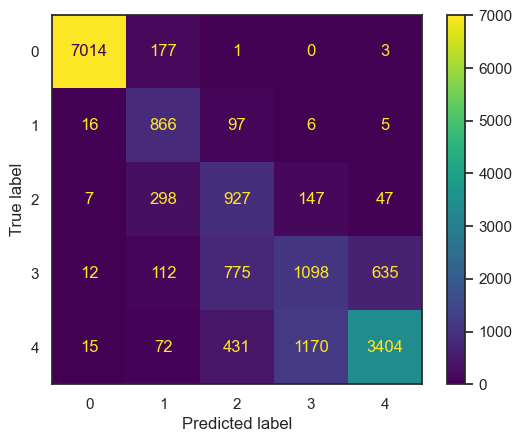

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9929    0.9748    0.9838      7195
           1     0.5679    0.8747    0.6887       990
           2     0.4155    0.6501    0.5070      1426
           3     0.4535    0.4172    0.4346      2632
           4     0.8315    0.6685    0.7411      5092

    accuracy                         0.7678     17335
   macro avg     0.6523    0.7171    0.6710     17335
weighted avg     0.7918    0.7678    0.7731     17335

Saved report for FCN fold 30min under 1
Bootstrapped Macro F1: 0.6710
95% CI: (0.6631, 0.6791)
Started for fold 2


2025-09-18 00:13:55.906722: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:15:18.546565: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 7s 5ms/step - loss: 0.6980 - sparse_categorical_accuracy: 0.6845


2025-09-18 00:15:25.161691: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 3s 2ms/step


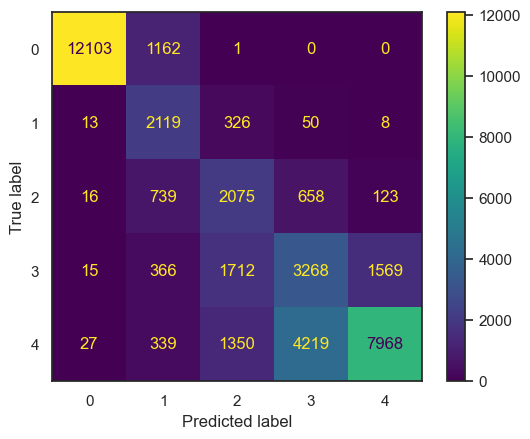

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9942    0.9123    0.9515     13266
           1     0.4485    0.8422    0.5853      2516
           2     0.3798    0.5746    0.4573      3611
           3     0.3988    0.4716    0.4321      6930
           4     0.8242    0.5731    0.6761     13903

    accuracy                         0.6845     40226
   macro avg     0.6091    0.6748    0.6205     40226
weighted avg     0.7436    0.6845    0.6996     40226

Saved report for FCN fold 30min under 2
Bootstrapped Macro F1: 0.6204
95% CI: (0.6154, 0.6256)
Started for fold 3


2025-09-18 00:15:44.346431: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:17:46.582766: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 3s 6ms/step - loss: 0.6226 - sparse_categorical_accuracy: 0.7269


2025-09-18 00:17:49.176278: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 1s 3ms/step


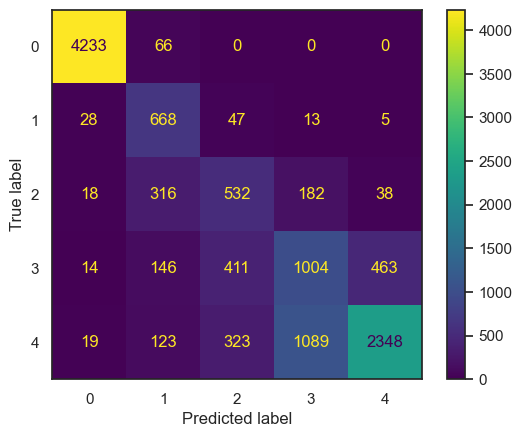

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9817    0.9846    0.9832      4299
           1     0.5064    0.8778    0.6423       761
           2     0.4052    0.4899    0.4435      1086
           3     0.4388    0.4926    0.4642      2038
           4     0.8227    0.6017    0.6951      3902

    accuracy                         0.7269     12086
   macro avg     0.6310    0.6893    0.6456     12086
weighted avg     0.7571    0.7269    0.7327     12086

Saved report for FCN fold 30min under 3
Bootstrapped Macro F1: 0.6460
95% CI: (0.6369, 0.6555)
Started for fold 4


2025-09-18 00:17:55.578900: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 00:19:36.680191: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 5s 5ms/step - loss: 0.6720 - sparse_categorical_accuracy: 0.6819


2025-09-18 00:19:41.838692: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 3s 3ms/step


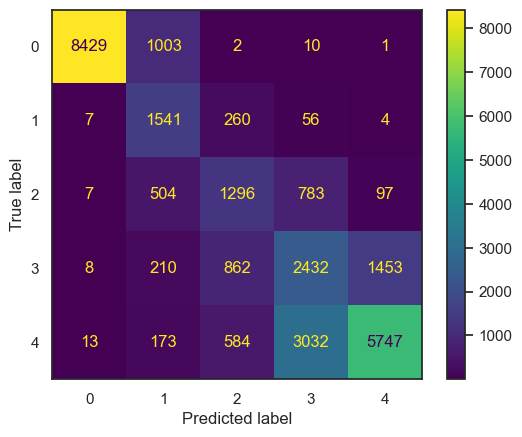

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9959    0.8924    0.9413      9445
           1     0.4491    0.8249    0.5816      1868
           2     0.4314    0.4823    0.4555      2687
           3     0.3852    0.4898    0.4313      4965
           4     0.7870    0.6018    0.6821      9549

    accuracy                         0.6819     28514
   macro avg     0.6097    0.6583    0.6184     28514
weighted avg     0.7306    0.6819    0.6963     28514

Saved report for FCN fold 30min under 4
Bootstrapped Macro F1: 0.6186
95% CI: (0.6125, 0.6245)
Report for FCN


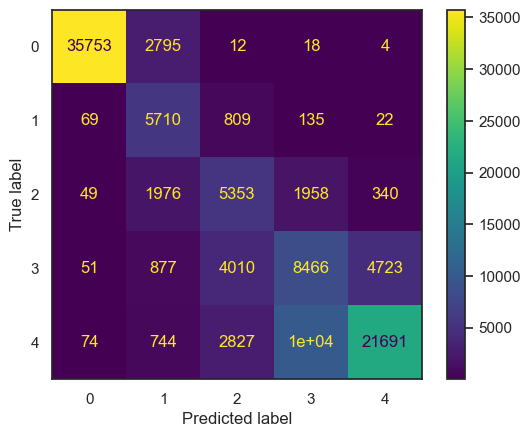

              precision    recall  f1-score   support

           0     0.9932    0.9267    0.9588     38582
           1     0.4718    0.8466    0.6059      6745
           2     0.4114    0.5532    0.4719      9676
           3     0.4099    0.4670    0.4366     18127
           4     0.8100    0.6125    0.6975     35415

    accuracy                         0.7091    108545
   macro avg     0.6193    0.6812    0.6341    108545
weighted avg     0.7518    0.7091    0.7210    108545



In [ ]:
# testing undersampling on train data

# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# intializes 5 folds 
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All_30min_under = []
predicted_labels_fcn_All_30min_under = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):
        
        average_precisions = []
        PRauc_scores = []
        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 2)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 2) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)

        # calling function to undersample majority classes
        X_train_fold, Y_train_fold = undersampling(X_train_fold, Y_train_fold)
        

        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_rs, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_rs, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

         # sets the learning rate of the Adam optimizer 
        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)


        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['sparse_categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        ConfusionMatrixDisplay.from_predictions(Y_test_t, y_pred_fcn)
        plt.show()

        report_fcn = classification_report(Y_test_t, y_pred_fcn, digits=4)
        print(report_fcn)

        actual_labels_All_30min_under.append(Y_test_t)
        predicted_labels_fcn_All_30min_under.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper = data_models.bootstrap_macro_f1(np.array(Y_test_t), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_t, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_t, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_t, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_t,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_t, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
        targ_multi = enc.fit_transform(Y_test_fold.reshape(-1, 1))
        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(targ_multi[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            ap_score = average_precision_score(targ_multi[:, cl], predictions_fcn[:, cl])
            average_precisions.append(ap_score)
            PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)

        count = count + 1

# POPULATION
print("Report for FCN")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All_30min_under), axis=1) 
ConfusionMatrixDisplay.from_predictions(flatten(actual_labels_All_30min_under), y_pred_fcn)
plt.show()

# calculating metric
print(classification_report(flatten(actual_labels_All_30min), y_pred_fcn, digits=4))

with open("FCN_5Fold_30min_undersampling.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

# Train FCN model with 30 min ISL and focal loss with HR and GLC vs only GLC

In [11]:
def create_X_Y_univariate(df, group_id = "PtID", sample_count= 25, hours = 2, modus = "h"):

    # generates time series with sliding window approach
    result = df.groupby(group_id).apply(lambda g: data_preprocessing.extract_valid_windows_GLC(g, expected_sample_count = sample_count,
    min_window_duration = np.timedelta64(hours, modus)))

    # filters out None values of subjects with insufficient data
    filtered_result = [item for item in result if item is not None]
    # unpacks the values
    X_data, Y_data = zip(*filtered_result)

    return X_data, Y_data

# extracts only CGM time series sequences of 30 minute length, corresponding to 7 consecutive datapoints
X_data, Y_data = create_X_Y_univariate(df_min_max_scaled, "PtID", 7, 30, 'm')

In [15]:
len(X_data)

48

2025-09-18 11:01:02.832574: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-18 11:01:02.832640: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-18 11:01:03.475732: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 11:06:57.039405: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/325 [..............................] - ETA: 1:12

2025-09-18 11:06:59.833951: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 1s 2ms/step


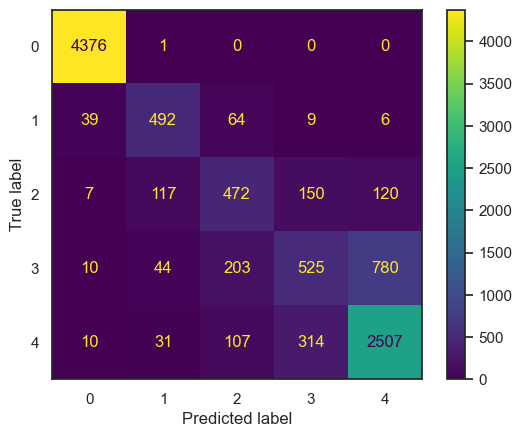

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9851    0.9998    0.9924      4377
           1     0.7182    0.8066    0.7598       610
           2     0.5579    0.5450    0.5514       866
           3     0.5261    0.3361    0.4102      1562
           4     0.7345    0.8444    0.7856      2969

    accuracy                         0.8062     10384
   macro avg     0.7044    0.7064    0.6999     10384
weighted avg     0.7931    0.8062    0.7953     10384

Saved report for FCN fold 30min focal GLC 0
Bootstrapped Macro F1: 0.6997
95% CI: (0.6890, 0.7102)
Started for fold 1


2025-09-18 11:07:03.920536: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 11:12:11.592362: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 3s 5ms/step - loss: 0.0477 - categorical_accuracy: 0.8049


2025-09-18 11:12:14.957186: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 1s 2ms/step


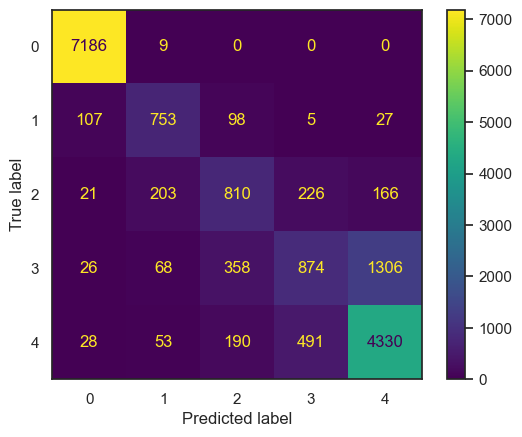

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9753    0.9987    0.9869      7195
           1     0.6934    0.7606    0.7254       990
           2     0.5563    0.5680    0.5621      1426
           3     0.5476    0.3321    0.4134      2632
           4     0.7428    0.8504    0.7930      5092

    accuracy                         0.8049     17335
   macro avg     0.7031    0.7020    0.6962     17335
weighted avg     0.7915    0.8049    0.7930     17335

Saved report for FCN fold 30min focal GLC 1
Bootstrapped Macro F1: 0.6963
95% CI: (0.6871, 0.7045)
Started for fold 2


2025-09-18 11:12:20.891290: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 11:16:10.483095: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 6s 4ms/step - loss: 0.0594 - categorical_accuracy: 0.7577


2025-09-18 11:16:16.399562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 3s 2ms/step


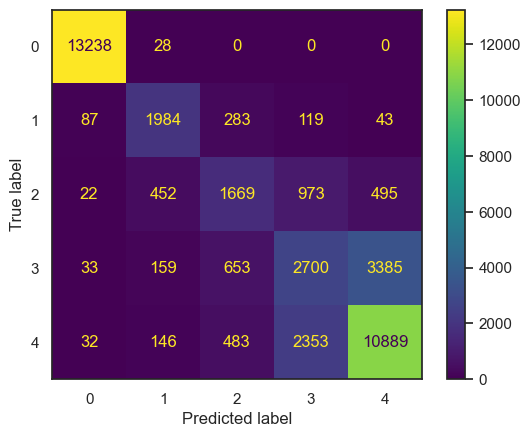

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9870    0.9979    0.9924     13266
           1     0.7165    0.7886    0.7508      2516
           2     0.5405    0.4622    0.4983      3611
           3     0.4394    0.3896    0.4130      6930
           4     0.7351    0.7832    0.7584     13903

    accuracy                         0.7577     40226
   macro avg     0.6837    0.6843    0.6826     40226
weighted avg     0.7486    0.7577    0.7523     40226

Saved report for FCN fold 30min focal GLC 2
Bootstrapped Macro F1: 0.6827
95% CI: (0.6777, 0.6882)
Started for fold 3


2025-09-18 11:16:29.611162: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 11:21:45.637271: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 2s 5ms/step - loss: 0.0590 - categorical_accuracy: 0.7578


2025-09-18 11:21:47.830905: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 1s 2ms/step


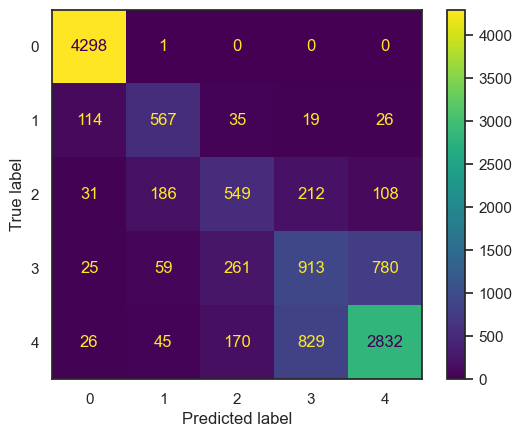

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9564    0.9998    0.9776      4299
           1     0.6608    0.7451    0.7004       761
           2     0.5409    0.5055    0.5226      1086
           3     0.4627    0.4480    0.4552      2038
           4     0.7560    0.7258    0.7406      3902

    accuracy                         0.7578     12086
   macro avg     0.6754    0.6848    0.6793     12086
weighted avg     0.7525    0.7578    0.7547     12086

Saved report for FCN fold 30min focal GLC 3
Bootstrapped Macro F1: 0.6795
95% CI: (0.6699, 0.6889)
Started for fold 4


2025-09-18 11:21:52.149499: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-18 11:26:05.370551: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 4s 4ms/step - loss: 0.0620 - categorical_accuracy: 0.7560


2025-09-18 11:26:09.583697: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 2s 2ms/step


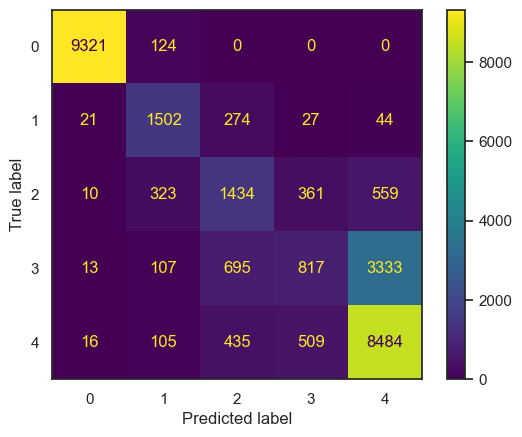

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9936    0.9869    0.9902      9445
           1     0.6950    0.8041    0.7456      1868
           2     0.5053    0.5337    0.5191      2687
           3     0.4767    0.1646    0.2446      4965
           4     0.6831    0.8885    0.7724      9549

    accuracy                         0.7560     28514
   macro avg     0.6707    0.6755    0.6544     28514
weighted avg     0.7340    0.7560    0.7270     28514

Saved report for FCN fold 30min focal GLC 4
Bootstrapped Macro F1: 0.6546
95% CI: (0.6488, 0.6607)
Report for FCN GLC focal loss


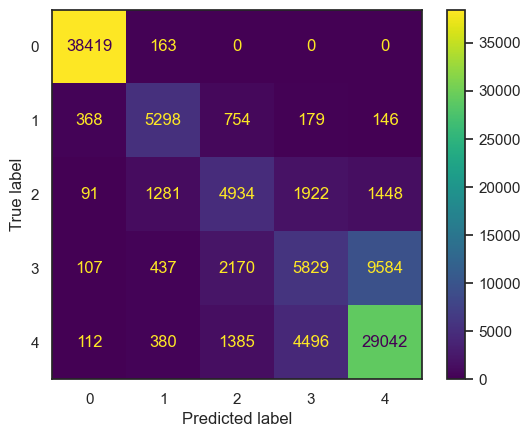

              precision    recall  f1-score   support

           0     0.9827    0.9958    0.9892     38582
           1     0.7009    0.7855    0.7408      6745
           2     0.5338    0.5099    0.5216      9676
           3     0.4691    0.3216    0.3816     18127
           4     0.7221    0.8200    0.7680     35415

    accuracy                         0.7695    108545
   macro avg     0.6817    0.6866    0.6802    108545
weighted avg     0.7544    0.7695    0.7584    108545



In [ ]:
# testing model with leveraging only CGM data

# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# intializes 5 folds
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual_labels_All_30min_focal_GLC = []
predicted_labels_fcn_All_30min_focal_GLC = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):
        
        average_precisions = []
        PRauc_scores = []
        

        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,7,1)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 1)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,7,1)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 1) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)


        Y_train_encoded = to_categorical(Y_train_fold)
        Y_test_encoded = to_categorical(Y_test_fold)

        # for class weights 
        Y_test_weights = Y_test_fold.reshape(-1).astype('int32')

        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
        focloss = tf.keras.losses.CategoricalFocalCrossentropy()
        
        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=['categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        y_true_labels = np.argmax(Y_test_t, axis=1)
        ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
        plt.show()
        
        report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
        print(report_fcn)

        actual_labels_All_30min_focal_GLC.append(Y_test_t)
        predicted_labels_fcn_All_30min_focal_GLC.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper = data_models.bootstrap_macro_f1(np.array(Y_test_rs), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
                f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
                sorted_indices = np.argsort(f_rec)
                pr_auc_scores = auc(f_rec, f_pre)
                ap_score = average_precision_score(Y_test_t[:, cl], predictions_fcn[:, cl])
                average_precisions.append(ap_score)
                PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)
        
        count = count + 1


# POPULATION
print("Report for FCN GLC focal loss")
y_pred_fcn = np.argmax(flatten(predicted_labels_fcn_All_30min_focal_GLC), axis=1) 
y_true_labels = np.argmax(flatten(actual_labels_All_30min_focal_GLC), axis=1)
ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
plt.show()
# calculating metric
print(classification_report(y_true_labels, y_pred_fcn, digits=4))

# saves the metrics to a txt file
with open("FCN_5Fold_30min_focal_GLC.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

## Best architecture is trained for 50 epochs (FCN model, 30 minute ISL, focal loss, only CGM data)

In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)

# initializes 5 folds
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)
with open("SDBII_5fold_indices.txt", "w", encoding="utf-8") as f:
    for fold, (train_idx, test_idx) in enumerate(kfolds.split(X_data), start=1):
        f.write(f"Fold {fold}\n")
        f.write("Train indices:\n")
        f.write(" ".join(map(str, train_idx)) + "\n")
        f.write("Test indices:\n")
        f.write(" ".join(map(str, test_idx)) + "\n")
        f.write("\n")

2025-09-23 20:24:05.979423: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-23 20:24:05.979632: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Started for fold 0


2025-09-23 20:24:07.207202: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-23 20:34:55.302338: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 3s 6ms/step - loss: 0.0471 - categorical_accuracy: 0.8012


2025-09-23 20:34:58.142806: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


325/325 [==============================] - 1s 2ms/step


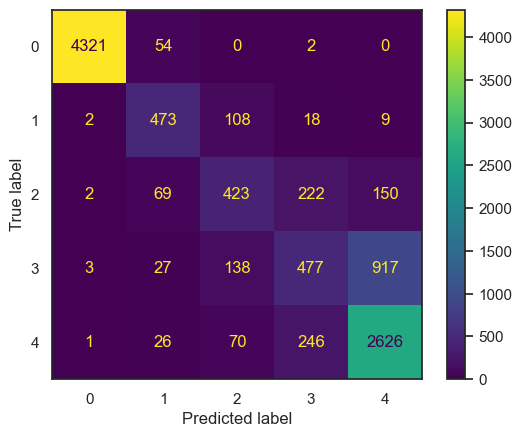

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9982    0.9872    0.9926      4377
           1     0.7288    0.7754    0.7514       610
           2     0.5724    0.4885    0.5271       866
           3     0.4943    0.3054    0.3775      1562
           4     0.7093    0.8845    0.7873      2969

    accuracy                         0.8012     10384
   macro avg     0.7006    0.6882    0.6872     10384
weighted avg     0.7885    0.8012    0.7884     10384

Saved report for 50 epoch FCN fold 30min focal GLC 0
Bootstrapped Macro F1: 0.6869
95% CI: (0.6759, 0.6978)
Started for fold 1


2025-09-23 20:35:02.431906: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-23 20:45:02.732580: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/542 [..............................] - ETA: 1:42

2025-09-23 20:45:05.700426: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


542/542 [==============================] - 1s 2ms/step


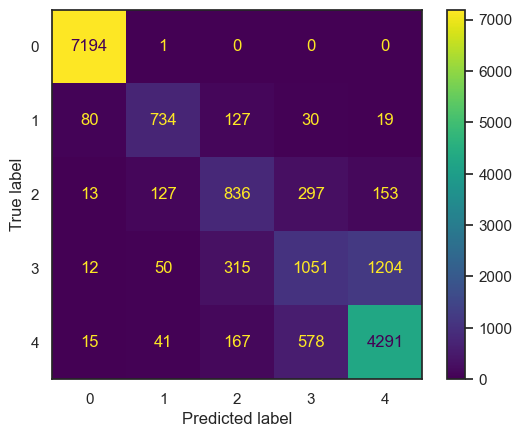

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9836    0.9999    0.9917      7195
           1     0.7702    0.7414    0.7555       990
           2     0.5785    0.5863    0.5824      1426
           3     0.5373    0.3993    0.4582      2632
           4     0.7572    0.8427    0.7977      5092

    accuracy                         0.8137     17335
   macro avg     0.7254    0.7139    0.7171     17335
weighted avg     0.8038    0.8137    0.8065     17335

Saved report for 50 epoch FCN fold 30min focal GLC 1
Bootstrapped Macro F1: 0.7171
95% CI: (0.7088, 0.7254)
Started for fold 2


2025-09-23 20:45:11.677274: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-23 20:52:39.908429: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 6s 4ms/step - loss: 0.0601 - categorical_accuracy: 0.7529


2025-09-23 20:52:46.303514: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1258/1258 [==============================] - 3s 2ms/step


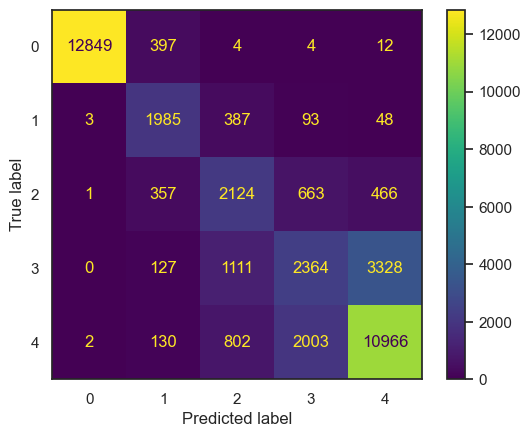

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9995    0.9686    0.9838     13266
           1     0.6626    0.7890    0.7202      2516
           2     0.4797    0.5882    0.5284      3611
           3     0.4611    0.3411    0.3921      6930
           4     0.7399    0.7888    0.7636     13903

    accuracy                         0.7529     40226
   macro avg     0.6686    0.6951    0.6776     40226
weighted avg     0.7493    0.7529    0.7484     40226

Saved report for 50 epoch FCN fold 30min focal GLC 2
Bootstrapped Macro F1: 0.6777
95% CI: (0.6725, 0.6832)
Started for fold 3


2025-09-23 20:53:00.262164: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-23 21:03:33.779356: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 3s 6ms/step - loss: 0.0553 - categorical_accuracy: 0.7673


2025-09-23 21:03:36.842494: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


378/378 [==============================] - 1s 2ms/step


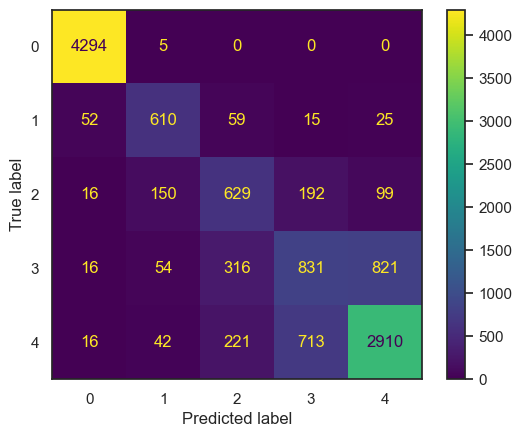

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9772    0.9988    0.9879      4299
           1     0.7085    0.8016    0.7522       761
           2     0.5135    0.5792    0.5444      1086
           3     0.4746    0.4078    0.4386      2038
           4     0.7549    0.7458    0.7503      3902

    accuracy                         0.7673     12086
   macro avg     0.6857    0.7066    0.6947     12086
weighted avg     0.7621    0.7673    0.7639     12086

Saved report for 50 epoch FCN fold 30min focal GLC 3
Bootstrapped Macro F1: 0.6949
95% CI: (0.6857, 0.7041)
Started for fold 4


2025-09-23 21:03:41.453064: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-09-23 21:12:26.186070: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  1/892 [..............................] - ETA: 3:00

2025-09-23 21:12:31.288582: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


892/892 [==============================] - 2s 2ms/step


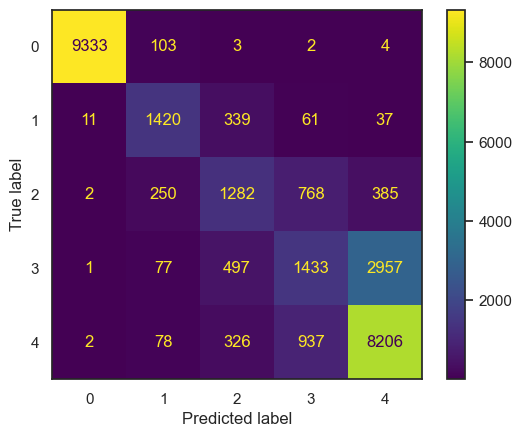

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9983    0.9881    0.9932      9445
           1     0.7365    0.7602    0.7482      1868
           2     0.5239    0.4771    0.4994      2687
           3     0.4477    0.2886    0.3510      4965
           4     0.7081    0.8594    0.7764      9549

    accuracy                         0.7601     28514
   macro avg     0.6829    0.6747    0.6736     28514
weighted avg     0.7434    0.7601    0.7462     28514

Saved report for 50 epoch FCN fold 30min focal GLC 4
Bootstrapped Macro F1: 0.6737
95% CI: (0.6675, 0.6798)
Report for FCN 50 GLC focal loss


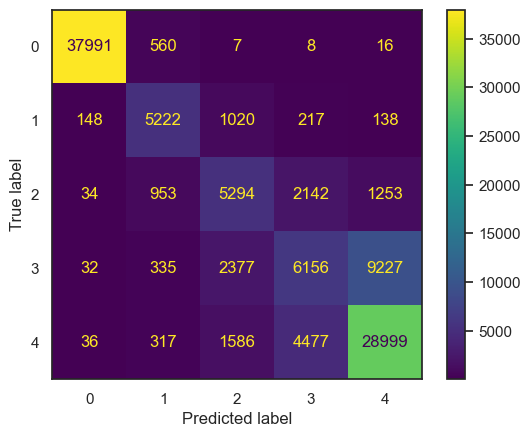

              precision    recall  f1-score   support

           0     0.9935    0.9847    0.9891     38582
           1     0.7069    0.7742    0.7390      6745
           2     0.5148    0.5471    0.5305      9676
           3     0.4735    0.3396    0.3955     18127
           4     0.7317    0.8188    0.7728     35415

    accuracy                         0.7708    108545
   macro avg     0.6841    0.6929    0.6854    108545
weighted avg     0.7607    0.7708    0.7630    108545



In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# initializes 5 folds
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

# empty list for predicted and actual values
actual50_labels_All_30min_focal_GLC = []
predicted50_labels_fcn_All_30min_focal_GLC = []

# empty list for accuracy and variables of each fold which are stored
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []

count = 0

for train_idx, test_idx in kfolds.split(X_data):
        
        average_precisions = []
        PRauc_scores = []

        print(f"Started for fold {count}")
        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]
        
        # flattens the arrays of single subjects into one array of shape (X,7,1)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 1)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,7,1)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 1) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)


        Y_train_encoded = to_categorical(Y_train_fold)
        Y_test_encoded = to_categorical(Y_test_fold)

        # for class weights 
        Y_test_weights = Y_test_fold.reshape(-1).astype('int32')

        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 64

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
        focloss = tf.keras.losses.CategoricalFocalCrossentropy()
        
      
        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=['categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=50, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        model_fcn.evaluate(X_test_t, Y_test_t)
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        y_true_labels = np.argmax(Y_test_t, axis=1)
        ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
        # saves confusion matrices
        name_img_test = "Images/Confusion_Matrices/SDBII_FCN_5FCV_30min_focal_GLC_%i.png" % (count)
        plt.savefig(name_img_test)
        plt.show()

        # saves model 
        name_fcn = "Models/Quality_Refined_SDBII/SDBII_FCN_5FCV_30min_FL_GLC_%i.hdf5" % (count)
        model_fcn.save(name_fcn)
        
        report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
        print(report_fcn)

        print(f"Saved report for 50 epoch FCN fold 30min focal GLC {count}")

        actual50_labels_All_30min_focal_GLC.append(Y_test_t)
        predicted50_labels_fcn_All_30min_focal_GLC.append(predictions_fcn)

        # Run bootstrapping
        mean_f1, ci_lower, ci_upper =data_models.bootstrap_macro_f1(np.array(Y_test_rs), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
                f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
                sorted_indices = np.argsort(f_rec)
                pr_auc_scores = auc(f_rec, f_pre)
                ap_score = average_precision_score(Y_test_t[:, cl], predictions_fcn[:, cl])
                average_precisions.append(ap_score)
                PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)


        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error(predictions_fcn,Y_test_fold)
        ECE.append(ece_score)
        
        count = count + 1


# POPULATION
print("Report for FCN 50 GLC focal loss")
y_pred_fcn = np.argmax(flatten(predicted50_labels_fcn_All_30min_focal_GLC), axis=1) 
y_true_labels = np.argmax(flatten(actual50_labels_All_30min_focal_GLC), axis=1)
ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
plt.show()

# calculating metric
print(classification_report(y_true_labels, y_pred_fcn, digits=4))

# saves metrics to txt file
with open("SDBII_FCN_5FCV_30min_FL_GLC.txt", "w") as f:
    actual_labels_All_under = []
    predicted_labels_fcn_under = []

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

# Metrics

In [ ]:
file= 'Reports/SDBII_FCN_5FCV_30min_FL_GLC.txt'

# general regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}

# helper function to extract numeric arrays
def extract_arrays(block_text):
    """Extracts all bracketed numeric arrays from a text block."""
    arrays = re.findall(r"\[([^\]]+)\]", block_text)
    parsed = [np.fromstring(a.replace(",", " "), sep=" ") for a in arrays]
    return np.array(parsed)

with open(file, "r") as f:
    text = f.read()

for metric_name, pattern in patterns.items():
    match = re.search(pattern, text)
    if not match:
        continue
    arrays = extract_arrays(match.group(1))
    if arrays.size == 0:
        continue

    if metric_name == "F1 Measure":
        f1_all = arrays
    elif metric_name == "Recall":
        recall_all = arrays
    elif metric_name == "Precision":
        precision_all = arrays
    elif metric_name == "PR AUC":
        pr_auc_all = arrays

# computes summary stats
def summarize(metric, name):
    if metric.size == 0:
        print(f"\n{name}: No data found.")
        return
    mean_per_class = np.mean(metric, axis=0)
    std_per_class = np.std(metric, axis=0)
    macro_mean = np.mean(mean_per_class)
    macro_std = np.std(mean_per_class)

    print(f"\n{name} Results:")
    print(f"Mean per Class: {np.round(mean_per_class, 4)}")
    print(f"Std per Class:  {np.round(std_per_class, 4)}")
    print(f"Macro Mean: {macro_mean:.4f}, Macro Std: {macro_std:.4f}")

# summarizes all metrics
summarize(f1_all, "F1 Measure")
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(pr_auc_all, "PR AUC")


F1 Measure Results:
Mean per Class: [0.9879 0.7364 0.5307 0.3873 0.77  ]
Std per Class:  [0.0055 0.0212 0.0231 0.0733 0.0189]
Macro Mean: 0.6825, Macro Std: 0.2069

Recall Results:
Mean per Class: [0.9966 0.781  0.5229 0.3341 0.8184]
Std per Class:  [0.0049 0.0243 0.0364 0.0947 0.0573]
Macro Mean: 0.6906, Macro Std: 0.2338

Precision Results:
Mean per Class: [0.9795 0.6968 0.5402 0.4905 0.7303]
Std per Class:  [0.013  0.0208 0.0189 0.0403 0.0249]
Macro Mean: 0.6875, Macro Std: 0.1719

PR AUC Results:
Mean per Class: [0.9999 0.792  0.5278 0.4359 0.8421]
Std per Class:  [0.     0.0214 0.0304 0.0337 0.0218]
Macro Mean: 0.7195, Macro Std: 0.2079
